## **Project Title**

### **Blood Cancer AI System: Detection, Severity & Cost Prediction (India)**

---

## **Business Problem**

In India, early detection of blood cancer and estimation of treatment costs remain challenging due to:

* Lack of accessible diagnostic support systems
* Limited awareness of disease severity levels
* Uncertainty in treatment cost across different cities

This creates difficulty for both:

* **Patients** - delayed decisions and financial uncertainty
* **Healthcare providers** - lack of decision-support tools

---

## **Project Overview**

This project develops a **supervised machine learning system** that performs three key tasks:

1. **Binary Classification** - Detect whether blood cancer is present or not
2. **Multi-class Classification** - Identify cancer severity (Low, Medium, High)
3. **Regression** - Predict treatment cost based on patient condition and city

The system uses structured medical and demographic data to generate predictions and can be deployed as a decision-support tool.

---

## **Problem Statement**

Develop a machine learning model that:

* Predicts the presence of blood cancer using clinical indicators
* Classifies the severity level of the disease
* Estimates treatment cost across major Indian cities

---

## **Goal**

### **Primary Goals:**
 
#### Classification Tasks
* Accurately detect blood cancer (Yes/No)
* Classify severity into **Low / Medium / High**
#### Regression Task
* Predict treatment cost in (₹ based on city & severity)

### **Secondary Goals:**

* Provide interpretable insights from medical features
* Support early-stage screening and cost awareness

---

## **Dataset Description**

The dataset contains **152,385 records** representing patient health data, symptoms, and location-based cost variations across **11 major Indian cities**.
 - `Mumbai, Delhi, Bangalore, Hyderabad, Chennai, Kolkata, Pune, Ahmedabad, Jaipur, Lucknow, Chandigarh.`
 

---

### **Column Description**

| Column Name         | Type       | Description                                                                                                  |
| ------------------  | ---------- | ------------------------------------------------------------------------------------------------------------ |
| **age**             |  int       | Age of the patient (in years). Helps identify risk patterns across age groups.                               |
| **gender**          |  category  | Patient gender (Male/Female). Used for demographic analysis.                                                 |
| **wbc**       |  int       | White Blood Cell count. Elevated levels may indicate infection or cancer conditions.                         |
| **rbc**       |  float     | Red Blood Cell count. Lower values can signal abnormalities such as anemia or cancer.                        |
| **platelets**       |  int       | Platelet count in blood. Abnormal levels are associated with blood disorders.                                |
| **hemoglobin**      |  float     | Hemoglobin level in blood. Low levels can indicate serious health conditions including cancer.               |
| **fever**           |	 binary    | Binary indicator (0/1). Represents whether the patient has a fever symptom [0 = No, 1 = Yes].                |
| **fatigue**         |  binary    | Binary indicator (0/1). Indicates presence of fatigue, a common symptom in cancer patients.[0 = No, 1 = Yes] |
| **weight_loss**     |  binary    | Binary indicator (0/1). Sudden weight loss is a key clinical symptom.[0 = No, 1 = Yes]                       |
| **city**            |  category  | Patient’s city from 11 major Indian cities. Used to model regional cost differences.           		  |
| **cancer_present**  |  binary    | Target variable (0/1). Indicates whether blood cancer is present.[0 = No, 1 = Yes]                           |
| **severity_level**    |  category  | Target variable ( None / Low / Medium / High). Represents severity of the disease.                    		  |
| **treatment_cost**  |  int(₹)    | Target variable (numeric, ₹). Estimated cost of treatment based on severity and location.      		  |

---
## **Import Required Libraries**
---

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

%matplotlib inline
plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", '{:.4f}'.format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (22,8)
plt.rcParams["figure.dpi"] = 120

import warnings
warnings.filterwarnings("ignore") 
warnings.filterwarnings("ignore", category=FutureWarning)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## **Data Understanding & Preprocessing**
---

### **Load Dataset**

In [2]:
# Load the Parquet file
df = pd.read_parquet(r"D:\Blood Cancer AI System\Main Folder\data\raw\blood_cancer_dataset.parquet")
print(f"Dataset loaded successfully\n")

# Check shape and columns
print(f"Shape of dataset: {df.shape}\n")
print("Columns:\n", df.columns.to_frame(index=False, name="Column Name"))

Dataset loaded successfully

Shape of dataset: (354298, 13)

Columns:
        Column Name
0              age
1           gender
2              wbc
3              rbc
4       hemoglobin
5        platelets
6            fever
7          fatigue
8      weight_loss
9             city
10  cancer_present
11  severity_level
12  treatment_cost


### **Quick Look**

In [3]:
# Preview Data
print("\nFirst 5 rows:")
display(df.head())
print("\nLast 5 rows:")
display(df.tail())
print("\nSample 5 rows:")
display(df.sample(5,  random_state=42))


First 5 rows:


,age,gender,wbc,rbc,hemoglobin,platelets,fever,fatigue,weight_loss,city,cancer_present,severity_level,treatment_cost
0,62,Female,11483,3.7400,10.9800,220307,0,0,0,Chennai,1,High,1491044.5100
1,52,Female,15893,3.5900,12.3400,137043,1,1,0,Jaipur,1,Low,115831.7700
2,64,Female,8930,3.8600,11.1900,118447,1,1,1,Hyderabad,1,High,1578648.8500
3,77,Female,8337,4.4200,8.6400,103390,1,1,1,Delhi,1,Medium,598684.0100
4,51,Male,10374,3.7600,10.9200,196707,1,0,0,Chennai,1,Medium,273321.5800



Last 5 rows:


,age,gender,wbc,rbc,hemoglobin,platelets,fever,fatigue,weight_loss,city,cancer_present,severity_level,treatment_cost
354293,27,Female,38247,4.4700,9.4900,218955,1,1,0,Delhi,1,Low,197377.8100
354294,2,Female,6284,4.7500,12.7700,247870,0,0,0,Jaipur,0,None,15516.5300
354295,42,Female,4045,5.3400,13.8700,244417,1,0,0,Jaipur,0,None,21557.9200
354296,69,Male,9392,5.3500,8.9000,151617,1,1,0,Delhi,1,High,1525916.9500
354297,57,Male,11477,4.1500,9.4700,123638,0,0,0,Bangalore,1,Low,127703.7000



Sample 5 rows:


,age,gender,wbc,rbc,hemoglobin,platelets,fever,fatigue,weight_loss,city,cancer_present,severity_level,treatment_cost
323634,46,Male,7311,5.4300,15.9700,433783,0,0,0,Hyderabad,0,None,10728.2100
181109,66,Female,9740,4.2000,14.1700,90907,1,0,1,Chandigarh,1,Low,96079.7700
259875,63,Male,5037,5.4300,15.5300,320924,0,0,0,Hyderabad,0,None,22865.1500
243506,61,Male,5706,5.3600,15.0500,257444,0,0,0,Ahmedabad,0,None,7971.8500
326003,82,Male,7635,6.0600,16.3100,347205,0,0,0,Bangalore,0,None,18152.1700


#### **Observation :**

* Dataset is large (354K rows, 13 features) - good for model training
* Contains mix of numerical, categorical, and binary features
* Target variables available for **classification + regression** tasks
* Data looks mostly structured and consistent (no obvious missing shown)
* Includes medical + symptom + city data - useful for prediction system
* Class labels include **0/1 (cancer)** and **Low/Medium/High severity** 


### **Duplicate Detection & Removal**

In [4]:
# Check duplicates
print(f"Are there duplicates?: {df.duplicated().any()}")
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
print(f"\nShape Before removing duplicates: {df.shape}")
df = df.drop_duplicates().reset_index(drop=True)
print("Shape After removing duplicates:", df.shape)

Are there duplicates?: True
Duplicate Rows: 142

Shape Before removing duplicates: (354298, 13)
Shape After removing duplicates: (354156, 13)


#### **Observation :**

- Dataset contains **142 duplicate rows**, which were removed, reducing the dataset size from **354,298 to 354,156** without significant data loss. 
ww

### **Data Types & Info**

In [5]:
print("Dataset Info:\n")
df.info()

Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 354156 entries, 0 to 354155
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   age             354156 non-null  int64  
 1   gender          354156 non-null  str    
 2   wbc             354156 non-null  int64  
 3   rbc             354156 non-null  float64
 4   hemoglobin      354156 non-null  float64
 5   platelets       354156 non-null  int64  
 6   fever           354156 non-null  int64  
 7   fatigue         354156 non-null  int64  
 8   weight_loss     354156 non-null  int64  
 9   city            354156 non-null  str    
 10  cancer_present  354156 non-null  int64  
 11  severity_level  354156 non-null  str    
 12  treatment_cost  354156 non-null  float64
dtypes: float64(3), int64(7), str(3)
memory usage: 40.8 MB


In [6]:
# Convert columns to category
con_cols = ["gender", "city", "severity_level"]
df[con_cols] = df[con_cols].astype("category")

# int64 - int16 & int8
df["age"] = df["age"].astype("int16")

bin_cols = ["fever", "fatigue", "weight_loss", "cancer_present"]
df[bin_cols] = df[bin_cols].astype("int8")

# Verify the change
display(df.dtypes)

age                  int16
gender            category
wbc                  int64
rbc                float64
hemoglobin         float64
platelets            int64
fever                 int8
fatigue               int8
weight_loss           int8
city              category
cancer_present        int8
severity_level    category
treatment_cost     float64
dtype: object

#### **Observation**

* Dataset has **354K+ records with no missing values** → clean and complete data
* Categorical columns converted to **category dtype** → memory optimized
* Binary columns converted to **int8** and age to **int16** → reduced memory usage
* Overall dataset is **well-structured and ready for analysis** with efficient storage

### **Unique Values per Column**

In [7]:
# Check unique values for each column
print(f"Unique value counts per column:\n")
for col in df.columns:
    print(f"Unique values in {col}: {df[col].nunique()}")

Unique value counts per column:

Unique values in age: 99
Unique values in gender: 2
Unique values in wbc: 53964
Unique values in rbc: 451
Unique values in hemoglobin: 1262
Unique values in platelets: 221746
Unique values in fever: 2
Unique values in fatigue: 2
Unique values in weight_loss: 2
Unique values in city: 11
Unique values in cancer_present: 2
Unique values in severity_level: 4
Unique values in treatment_cost: 348657


#### **Observation:**

* Numerical features (wbc, platelets, treatment_cost) show **very high cardinality**, indicating continuous real-world medical values.
* Categorical features (gender, symptoms) are **binary and clean**, suitable for direct modeling.
* City has **moderate diversity (11)**, useful for cost variation analysis.
* Target variables are well-defined: **binary (cancer_present)** and **multi-class (severity_level)**.
* Overall, dataset is **rich, realistic, and suitable for classification + regression tasks** 


### **Identify Numerical & Categorical Columns**

In [8]:
# Identify numerical and categorical columns
num_cols = df.select_dtypes(include=["int64","int8","int16", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["category"]).columns.tolist()
print(f"Numerical Columns ({len(num_cols)}): {num_cols}")
print(f"\nCategorical Columns ({len(cat_cols)}): {cat_cols}")

Numerical Columns (10): ['age', 'wbc', 'rbc', 'hemoglobin', 'platelets', 'fever', 'fatigue', 'weight_loss', 'cancer_present', 'treatment_cost']

Categorical Columns (3): ['gender', 'city', 'severity_level']


### **Summary Statistics**

In [9]:
# Summary statistics for columns
print("Numerical Summary:\n")
display(df[num_cols].describe().T.round(2))
print("Categorical Summary:\n")
display(df[cat_cols].describe())

Numerical Summary:



,count,mean,std,min,25%,50%,75%,max
age,354156.0000,47.7900,18.6900,1.0000,36.0000,49.0000,61.0000,99.0000
wbc,354156.0000,15047.0700,16695.1500,1000.0000,6395.0000,8250.0000,16603.0000,100000.0000
rbc,354156.0000,4.5400,0.6900,2.0000,4.0800,4.5600,5.0200,6.5000
hemoglobin,354156.0000,12.5800,2.1200,5.0000,11.0300,12.7300,14.2000,18.0000
platelets,354156.0000,192058.0400,102015.4400,5000.0000,112554.0000,169934.0000,269482.2500,450000.0000
fever,354156.0000,0.3500,0.4800,0.0000,0.0000,0.0000,1.0000,1.0000
fatigue,354156.0000,0.3500,0.4800,0.0000,0.0000,0.0000,1.0000,1.0000
weight_loss,354156.0000,0.2200,0.4200,0.0000,0.0000,0.0000,0.0000,1.0000
cancer_present,354156.0000,0.5500,0.5000,0.0000,0.0000,1.0000,1.0000,1.0000
treatment_cost,354156.0000,347192.2100,464613.9300,4753.1500,17700.8000,105599.1200,544193.9200,1949979.5100


Categorical Summary:



,gender,city,severity_level
count,354156,354156,354156
unique,2,11,4
top,Female,Delhi,None
freq,182288,32434,160079


#### **Observations**

* **Age** centered around ~48 -> middle-aged population dominates.
* **WBC & Platelets** show **high variance and extreme max values**
* **RBC & Hemoglobin** are relatively stable -> medically consistent ranges.
* Binary symptoms (**fever, fatigue, weight_loss**) are **low prevalence** (~22–35%).
* Target variable **cancer_present is slightly imbalanced (55% = 1)**.
* **Treatment cost is highly skewed** (huge std, max ~19L ₹)
* Categorical features are simple (**low cardinality**).
* **Severity_level has “None” as majority** - aligns with cancer absence cases.

###  **Value Counts for Categorical Features**

In [10]:
 # Value counts for each categorical column
for col in cat_cols:
    vc = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(2)

    summary_cat = pd.concat([vc, pct], axis=1)
    summary_cat.columns = ["Count", "Percentage (%)"]
    
    print(f"\nValue counts for {col}:")
    display(summary_cat)


Value counts for gender:


,Count,Percentage (%)
gender,,
Female,182288,51.4700
Male,171868,48.5300



Value counts for city:


,Count,Percentage (%)
city,,
Delhi,32434,9.1600
Hyderabad,32392,9.1500
Pune,32268,9.1100
Chandigarh,32251,9.1100
Chennai,32222,9.1000
Lucknow,32203,9.0900
Mumbai,32138,9.0700
Ahmedabad,32136,9.0700
Kolkata,32089,9.0600



Value counts for severity_level:


,Count,Percentage (%)
severity_level,,
None,160079,45.2000
High,70534,19.9200
Medium,67277,19.0000
Low,56266,15.8900


#### **Observations**

* **Gender:** Nearly balanced distribution (Female ~51%, Male ~49%) - no strong gender bias.
* **City:** Uniform distribution across 11 cities (~9% each) - dataset is geographically well-balanced.
* **Severity Level:** Majority are **None (~45%)**, while **High/Medium/Low** are moderately distributed →- slight class imbalance toward non-cancer cases.

Overall: Dataset is **well-balanced for demographics and location**, but **target variable (severity)** shows imbalance that may affect model performance.

In [11]:
con_cols = ["gender", "city", "severity_level"]
df[con_cols] = df[con_cols].apply(lambda x: x.str.lower()).astype("category")

# Verify the change
display(df.dtypes)

age                  int16
gender            category
wbc                  int64
rbc                float64
hemoglobin         float64
platelets            int64
fever                 int8
fatigue               int8
weight_loss           int8
city              category
cancer_present        int8
severity_level    category
treatment_cost     float64
dtype: object

### **Missing Value Check**

In [12]:
# Check missing values
print(f"Are there any missing values?: {df.isnull().values.any()}")
print(f"Missing Values Count: {df.isnull().sum().sum()}\n")

print("Missing Values Percentage:")
print((df.isnull().sum() / len(df)) * 100)

Are there any missing values?: False
Missing Values Count: 0

Missing Values Percentage:
age              0.0000
gender           0.0000
wbc              0.0000
rbc              0.0000
hemoglobin       0.0000
platelets        0.0000
fever            0.0000
fatigue          0.0000
weight_loss      0.0000
city             0.0000
cancer_present   0.0000
severity_level   0.0000
treatment_cost   0.0000
dtype: float64


#### **Observation:**
No missing values are present in the dataset (0% across all features), indicating a fully complete and clean dataset ready for modeling without imputation. 


### **Data Consistency & Standardization**

In [13]:
print("Genders :", df["gender"].unique())
print("\nSeverity levels:", df["severity_level"].unique())
print("\nCity:", df["city"].unique())

Genders : ['female', 'male']
Categories (2, str): ['female', 'male']

Severity levels: ['high', 'low', 'medium', 'none']
Categories (4, str): ['high', 'low', 'medium', 'none']

City: ['chennai', 'jaipur', 'hyderabad', 'delhi', 'ahmedabad', ..., 'chandigarh', 'lucknow', 'bangalore', 'kolkata', 'pune']
Length: 11
Categories (11, str): ['ahmedabad', 'bangalore', 'chandigarh', 'chennai', ..., 'kolkata', 'lucknow', 'mumbai', 'pune']


In [14]:
# Check for invalid values
print("\nInvalid Age (<0 or >100):", df[(df["age"] < 0) | (df["age"] > 99)].shape[0])
print("Invalid WBC (<0):", (df["wbc"] <= 0).sum())
print("Invalid RBC (<0):", (df["rbc"] <= 0).sum())
print("Invalid Platelets (<0):", (df["platelets"] <= 0).sum())
print("Invalid Hemoglobin (<0):", (df["hemoglobin"] <= 0).sum())


Invalid Age (<0 or >100): 0
Invalid WBC (<0): 0
Invalid RBC (<0): 0
Invalid Platelets (<0): 0
Invalid Hemoglobin (<0): 0


##### **Observation:**

* Gender and severity features are well-defined categorical variables with no inconsistencies.
* City feature contains 11 valid categories representing major locations.
* No invalid values detected in key numerical features (age, WBC, RBC, platelets, hemoglobin).
* Overall, the dataset is clean, consistent, and ready for modeling without major data quality issues.

(Aligned with dataset structure and validation checks in the project) 

In [15]:
# Clinical range validation 
range_checks = {
    'age': (1, 100),
    'wbc': (2000, 130000),
    'rbc': (1.5, 7.0),
    'platelets': (5000, 450000),
    'hemoglobin': (3.0, 20.0)}

for col in range_checks:    
    # Get valid range
    low, high = range_checks[col]   
    # Count invalid values
    invalid_count = ((df[col] < low) | (df[col] > high)).sum()    
    # Total values
    total = df[col].shape[0]    
    # Percentage of invalid values
    percent = (invalid_count / total) * 100    
    # Status
    status = "OK" if invalid_count == 0 else "WARNING"    
    # Print result
    print(f"{col}: {invalid_count} invalid values ({percent:.2f}%) | Range [{low}, {high}] -> {status}")

age: 0 invalid values (0.00%) | Range [1, 100] -> OK
wbc: 2516 invalid values (0.71%) | Range [2000, 130000] -> WARNING
rbc: 0 invalid values (0.00%) | Range [1.5, 7.0] -> OK
platelets: 0 invalid values (0.00%) | Range [5000, 450000] -> OK
hemoglobin: 0 invalid values (0.00%) | Range [3.0, 20.0] -> OK


#### **Observation:**

All clinical features mostly fall within valid medical ranges with minimal invalid values; however, elevated WBC values are expected and **should not be treated as outliers** since they represent a key cancer signal.

**Note:-**

WBC count is a **key discriminative feature with a bimodal distribution**, where elevated values indicate cancer; treating these as outliers would remove the primary predictive signal. 


## **Outlier Detection & Treatment**
---

In [16]:
# Check outliers
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers

cols_to_check = ["wbc","rbc","hemoglobin", "platelets", "treatment_cost"]
for col in cols_to_check:
    outliers = detect_outliers(df, col)
    count = outliers.shape[0]
    percent = (count / len(df)) * 100
    print(f"{col:15} | Outliers: {count:<5} | Percentage: {percent:.2f}%")

wbc             | Outliers: 39023 | Percentage: 11.02%
rbc             | Outliers: 1950  | Percentage: 0.55%
hemoglobin      | Outliers: 275   | Percentage: 0.08%
platelets       | Outliers: 0     | Percentage: 0.00%
treatment_cost  | Outliers: 22874 | Percentage: 6.46%


#### **Observation:**

* High outliers in **WBC (11.02%)** and **treatment_cost (6.46%)** are **medically valid**, not noise.
* Other features show **negligible or no outliers**.
* No aggressive outlier removal required to preserve clinical patterns. 

## **Target Variable Analysis**
---

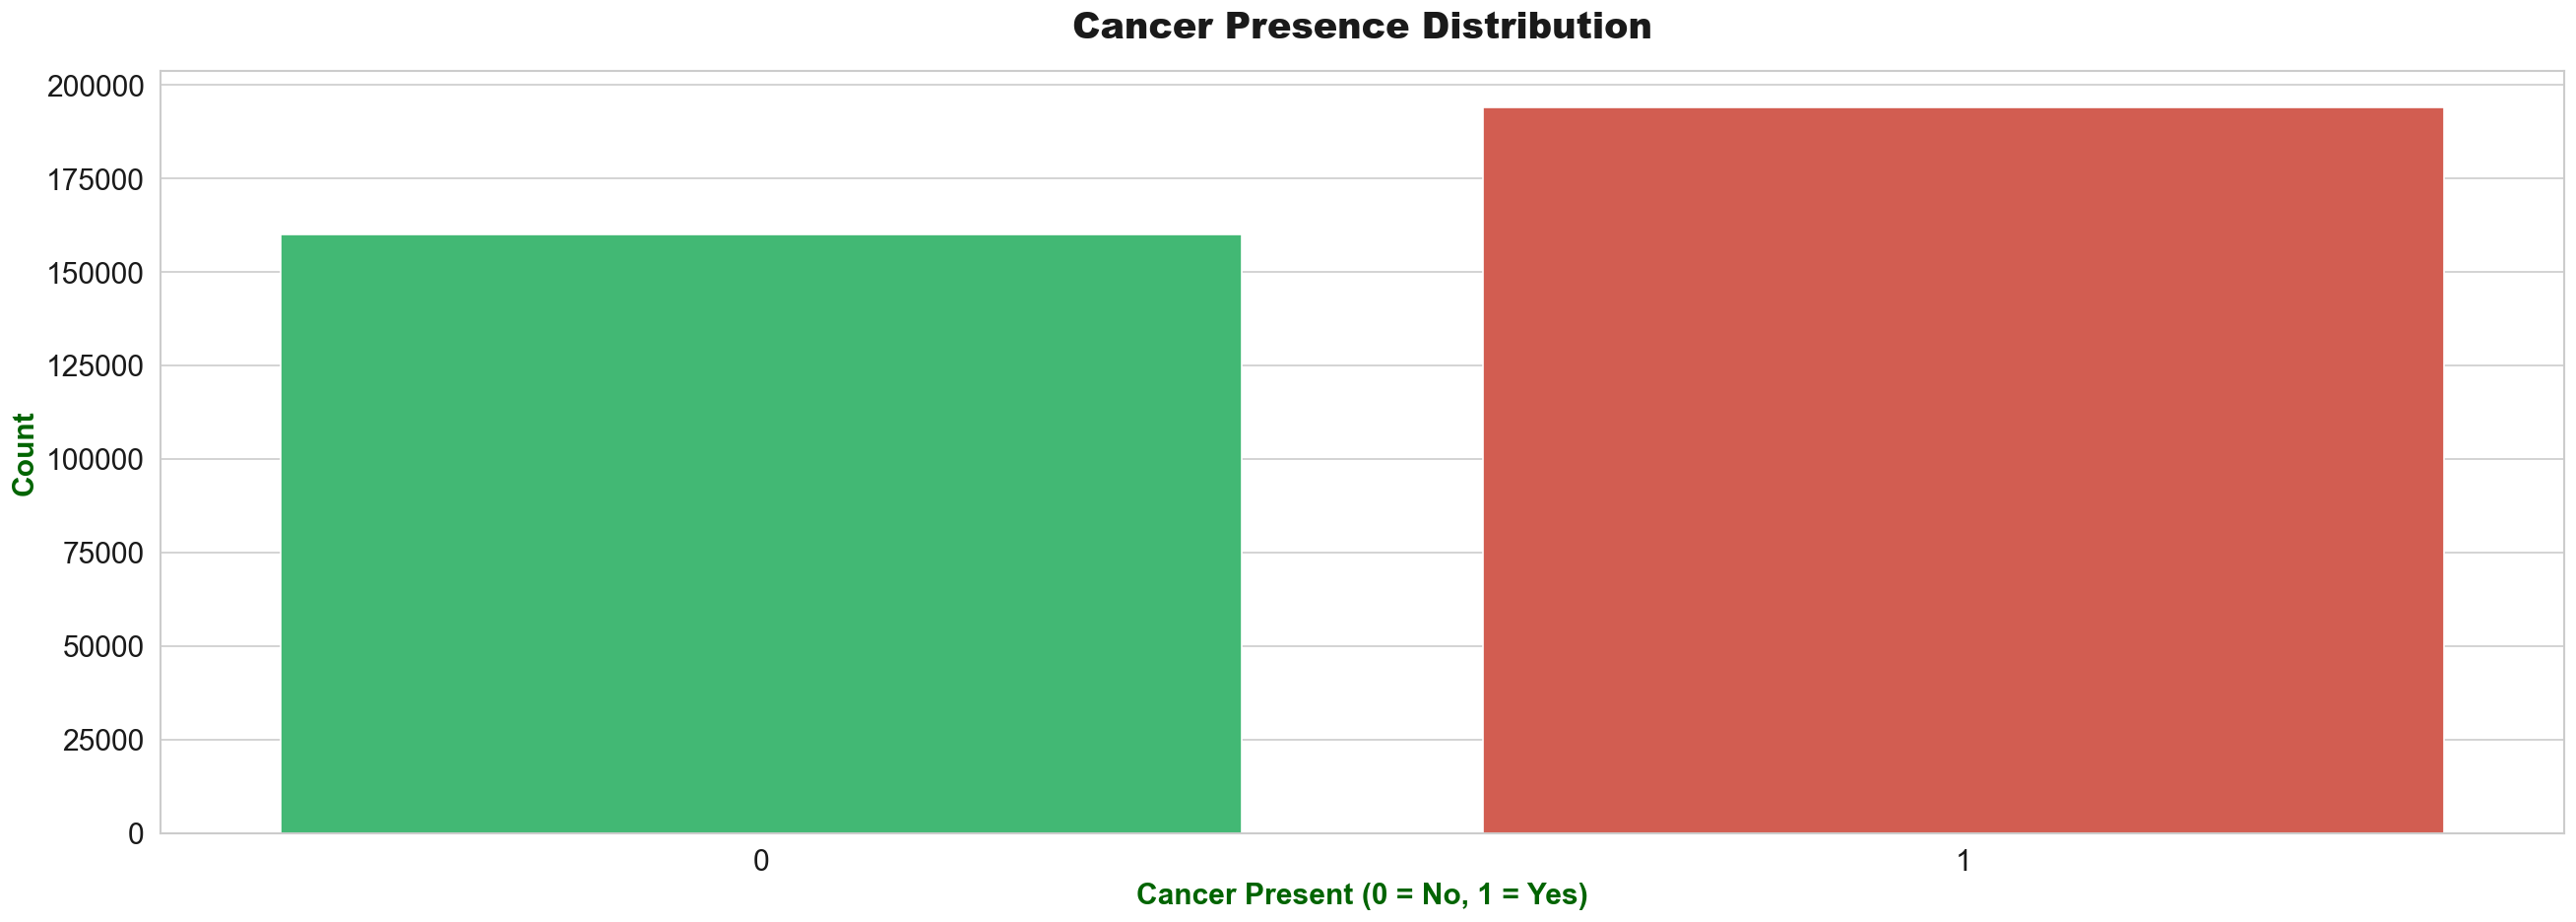

Counts:
                  count
cancer_present        
1               194077
0               160079

Percentages (%):
                 proportion
cancer_present            
1                  54.8000
0                  45.2000


In [17]:
# Analyze Cancer Detection (Binary Target)
plt.figure(figsize=(22, 8))
sns.countplot(x="cancer_present", data=df, palette=['#2ecc71', '#e74c3c'])

plt.title("Cancer Presence Distribution", fontsize=22, color="k", fontweight="heavy", pad=20)
plt.xlabel("Cancer Present (0 = No, 1 = Yes)", fontsize=18, color="darkgreen", fontweight="bold")
plt.ylabel("Count", fontsize=18, color="darkgreen", fontweight="bold")
plt.xticks(fontsize=18, color="k")
plt.yticks(fontsize=18, color="k")
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Cancer Presence Distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

counts = df["cancer_present"].value_counts()
percentages = df["cancer_present"].value_counts(normalize=True) * 100
print("Counts:\n", counts.to_frame())
print("\nPercentages (%):\n", percentages.round(2).to_frame())

In [18]:
print("Target Variable (Cancer Present) Summary:")
print(df["cancer_present"].describe().to_frame())
# Skewness
print(f"\nSkewness of Cancer Present: {df["cancer_present"].skew():.2f}")

Target Variable (Cancer Present) Summary:
       cancer_present
count     354156.0000
mean           0.5480
std            0.4977
min            0.0000
25%            0.0000
50%            1.0000
75%            1.0000
max            1.0000

Skewness of Cancer Present: -0.19


#### **Observation:**

* Target is **slightly imbalanced** (≈55% cancer, 45% no cancer) but acceptable for modeling.
* Distribution is **nearly balanced**, no major skew issues (skew = -0.19).
* Suitable for classification without heavy imbalance handling.

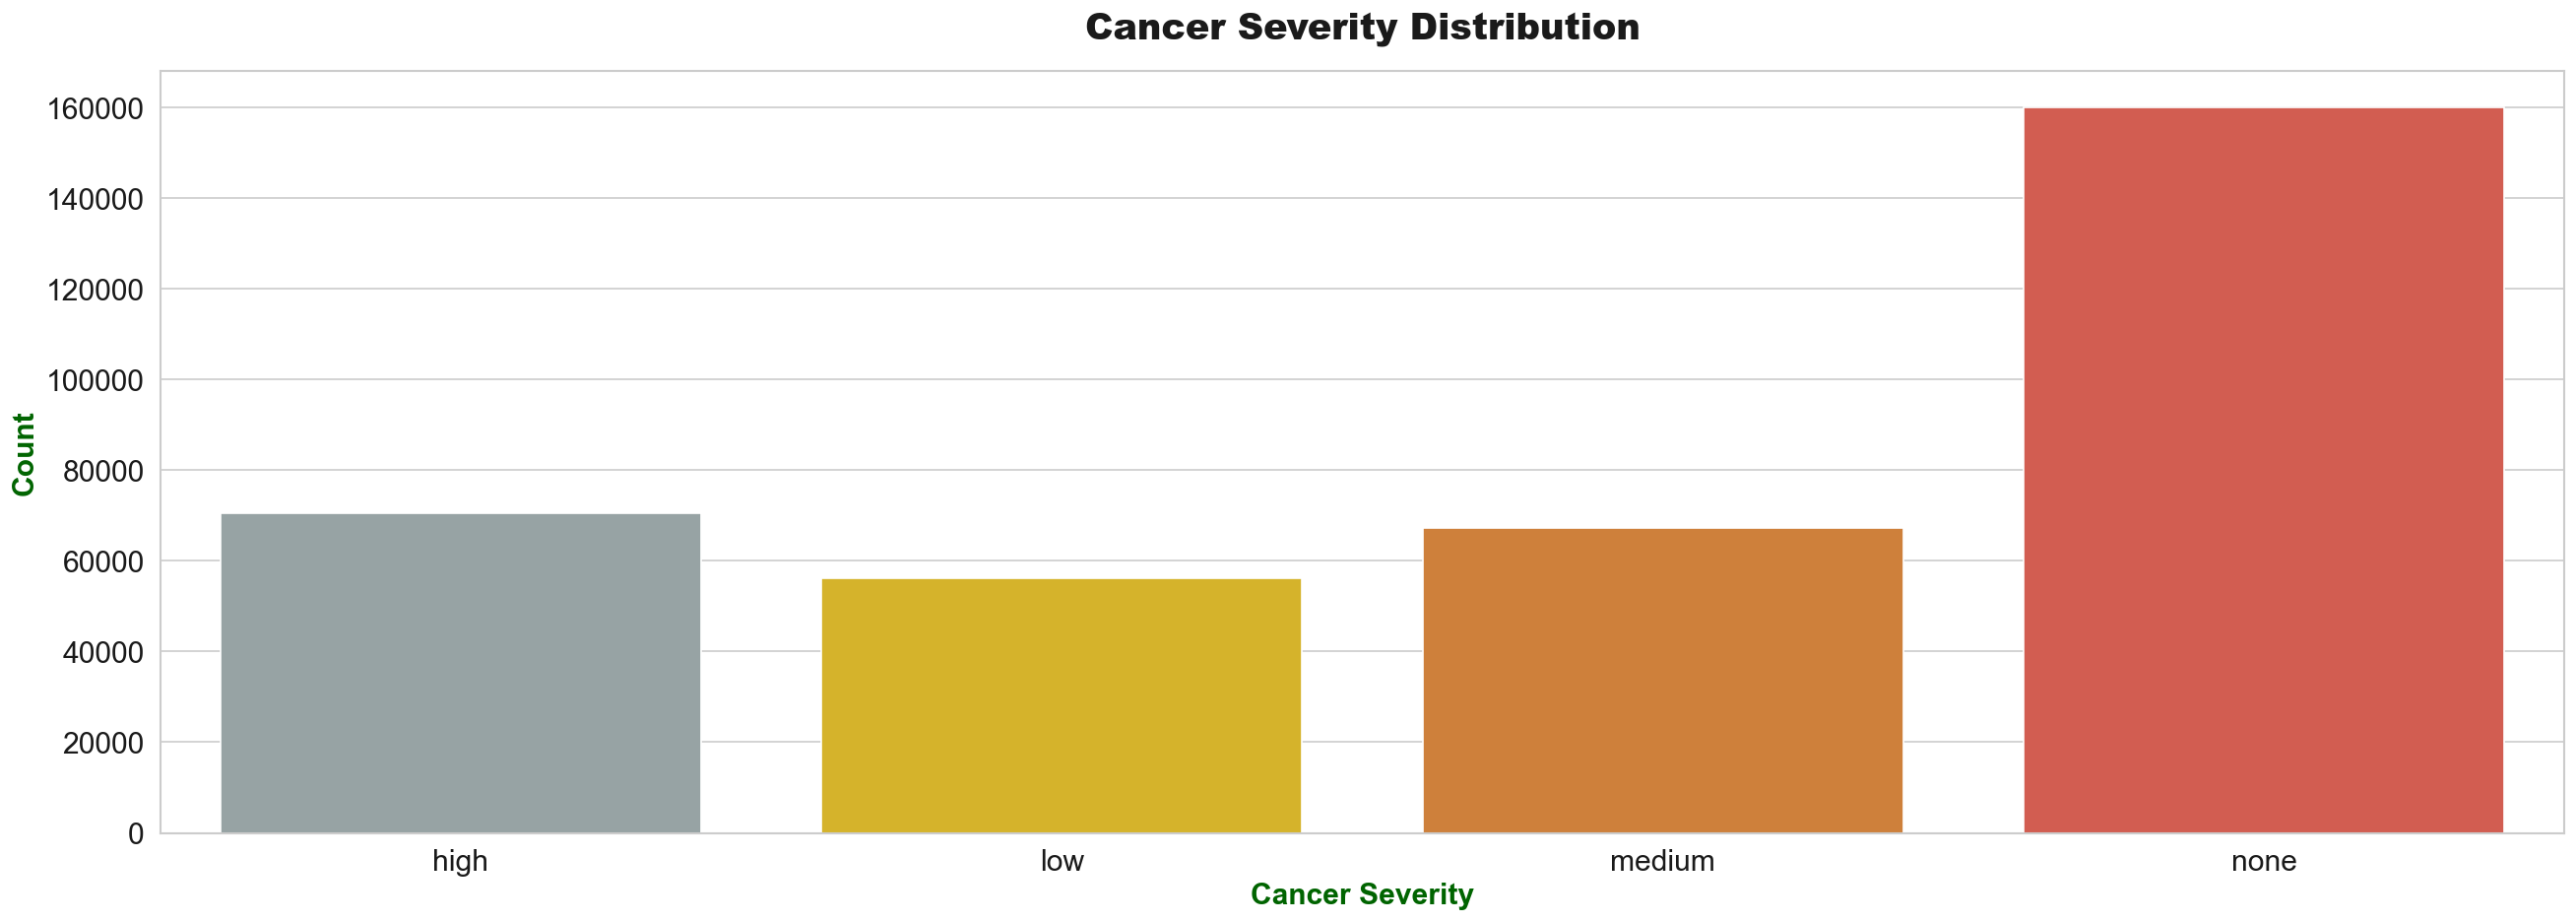

Counts:
                  count
severity_level        
none            160079
high             70534
medium           67277
low              56266

Percentages (%):
                 proportion
severity_level            
none               45.2000
high               19.9200
medium             19.0000
low                15.8900


In [19]:
# Analyze Severity (Multi-Class Target)
plt.figure(figsize=(22, 8))
counts = df["severity_level"].value_counts()
percentages = df["severity_level"].value_counts(normalize=True) * 100
sns.barplot(x=counts.index, y=counts.values,
    palette=['#95a5a6', '#f1c40f', '#e67e22', '#e74c3c'])

plt.title("Cancer Severity Distribution", fontsize=22, color="k", fontweight="heavy", pad=20)
plt.xlabel("Cancer Severity", fontsize=18, color="darkgreen", fontweight="bold")
plt.ylabel("Count", fontsize=18, color="darkgreen", fontweight="bold")
plt.xticks(fontsize=18, color="k")
plt.yticks(fontsize=18, color="k")
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Cancer Severity Distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Counts:\n", counts.to_frame())
print("\nPercentages (%):\n", percentages.round(2).to_frame())

#### **Observation:**

* Majority class is **“none” (45.2%)**, indicating many patients have no cancer.
* Among cancer cases, **high (19.9%) and medium (19.0%) dominate**, with **low (15.9%)** being least.
* Dataset shows **moderate class imbalance**, especially between *none vs severity levels*.


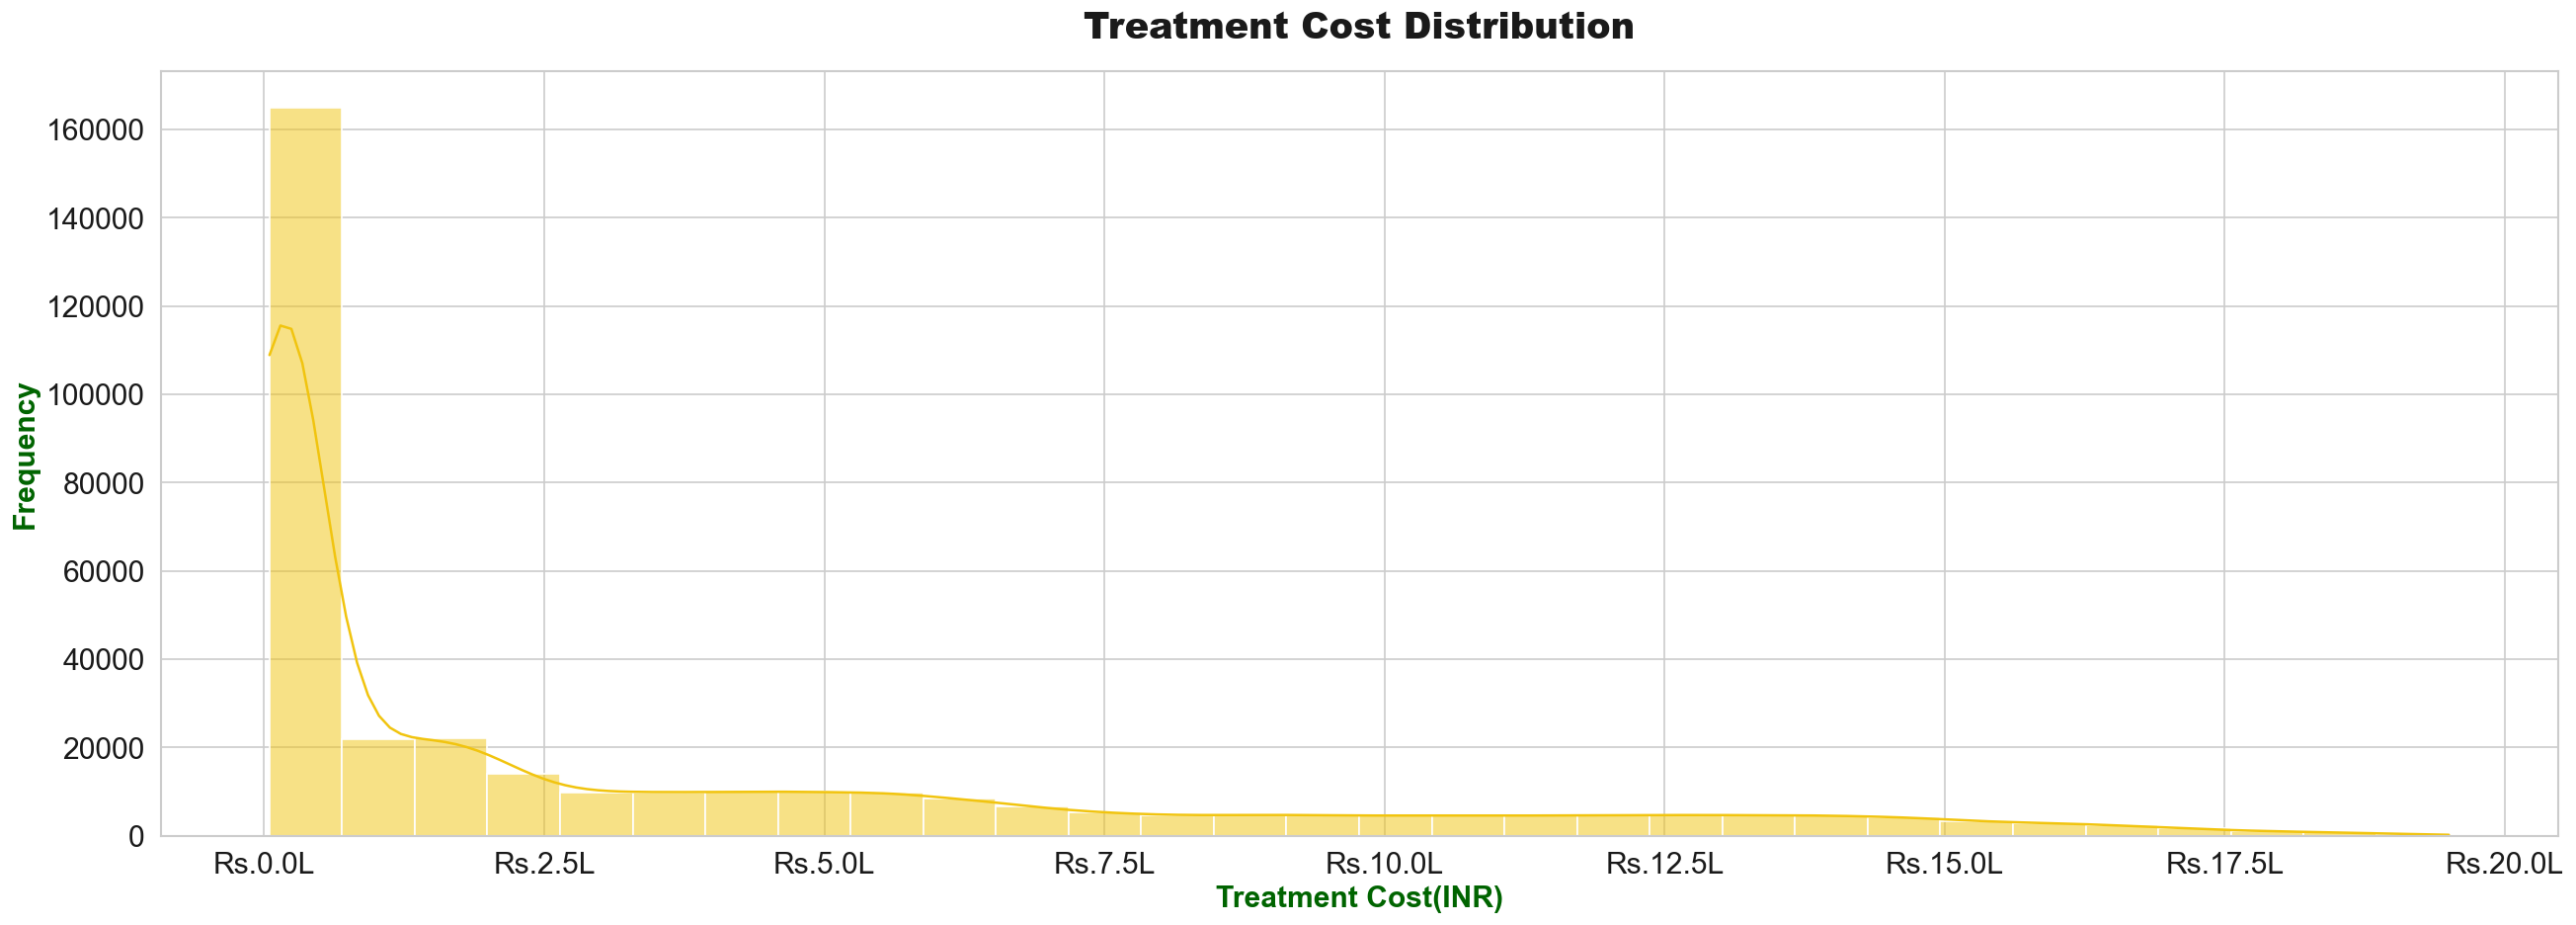

,treatment_cost
count,354156.0000
mean,347192.2055
std,464613.9262
min,4753.1500
25%,17700.7950
50%,105599.1200
75%,544193.9200
max,1949979.5100



Skewness of Treatment Cost: 1.42


In [20]:
# Analyze Treatment Cost
plt.figure(figsize=(22, 8))
sns.histplot(df["treatment_cost"], kde=True, bins=30, color="#f1c40f")

plt.title("Treatment Cost Distribution", fontsize=22, color="k", fontweight="heavy", pad=20)
plt.xlabel("Treatment Cost(INR)", fontsize=18, color="darkgreen", fontweight="bold")
plt.ylabel("Frequency", fontsize=18, color="darkgreen", fontweight="bold")

plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs.{x/1e5:.1f}L'))

plt.xticks(fontsize=18, color="k")
plt.yticks(fontsize=18, color="k")
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Treatment Cost Distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()
display(df["treatment_cost"].describe().to_frame())
# Skewness
print(f"\nSkewness of Treatment Cost: {df["treatment_cost"].skew():.2f}")

#### **Observation:**

* Treatment cost is **highly right-skewed (skew = 1.42)** with extreme high-cost cases.
* Majority of patients fall in **lower cost range**, but few cases drive very high costs.
* High variance - important for regression modeling (consider log transformation).


## **Feature Engineering**
----

In [21]:
# Feature Engineering
df_eng = df.copy()

# symptom_count :- Patients with multiple symptoms simultaneously have higher cancer risk.
df_eng["symptom_count"] = df_eng[["fever", "fatigue", "weight_loss"]].sum(axis=1)

# wbc_abnormal :- WBC > 11,000 is leukocytosis - a significant medical flag.
df_eng["wbc_abnormal"] = (
    (df_eng["wbc"] > 11000) | (df_eng["wbc"] < 4000)).astype(int)

# wbc-to-platelet ratio :- elevated WBC with low platelets is a blood cancer indicator
df_eng["wbc_platelet_ratio"] = np.where(
    df_eng["platelets"] == 0, np.nan,
    df_eng["wbc"] / df_eng["platelets"])

# Anemia indicator — low hemoglobin is a key blood cancer symptom
# Normal range: Men > 13.5, Women > 12.0
df_eng["anemia_flag"] = (
    ((df_eng["gender"] == "female") & (df_eng["hemoglobin"] < 12.0)) |
    ((df_eng["gender"] == "male") & (df_eng["hemoglobin"] < 13.5))).astype(int)

# thrombocytopenia_flag :- Platelets < 100,000 = clinically defined thrombocytopenia.
df_eng["thrombocytopenia_flag"] = (df_eng["platelets"] < 100000).astype(int)

# city_tier - encodes healthcare cost domain knowledge
tier_map = {
    'mumbai':1,'delhi':1,'bangalore':1,
    'hyderabad':2,'chennai':2,'kolkata':2,'pune':2,
    'ahmedabad':3,'jaipur':3,'lucknow':3,'chandigarh':3}

df_eng["city_tier"] = df_eng["city"].map(tier_map)

# clinical_risk_score
# Weighted composite of key blood markers - domain-guided signal.
wbc_n  = (df_eng["wbc"]  - df_eng["wbc"].min())  / (df_eng["wbc"].max()  - df_eng["wbc"].min())
hemo_n = 1 - ((df_eng["hemoglobin"] - df_eng["hemoglobin"].min()) / (df_eng["hemoglobin"].max() - df_eng["hemoglobin"].min()))
plt_n  = 1 - ((df_eng["platelets"]  - df_eng["platelets"].min())  / (df_eng["platelets"].max()  - df_eng["platelets"].min()))

df_eng["clinical_risk_score"] = (0.40 * wbc_n + 0.35 * hemo_n + 0.25 * plt_n).round(4)

# age_group :- bucketed for capturing non-linear age effects
bins   = [0, 18, 35, 50, 65, 99]
labels = ["Child","Young Adult","Middle-Aged","Senior","Elderly"]

df_eng["age_group"] = pd.cut(df_eng["age"], bins=bins, labels=labels)

print("New features created:")
new_feats = ['symptom_count','wbc_abnormal','anemia_flag', 'wbc_platelet_ratio',
             'thrombocytopenia_flag','city_tier','clinical_risk_score', 'age_group']

display(df_eng[new_feats].drop(columns=["city_tier", "age_group"]).describe().T)

New features created:


,count,mean,std,min,25%,50%,75%,max
symptom_count,354156.0000,0.9254,0.9959,0.0000,0.0000,1.0000,2.0000,3.0000
wbc_abnormal,354156.0000,0.3992,0.4897,0.0000,0.0000,0.0000,1.0000,1.0000
anemia_flag,354156.0000,0.4903,0.4999,0.0000,0.0000,0.0000,1.0000,1.0000
wbc_platelet_ratio,354156.0000,0.1662,0.5339,0.0029,0.0250,0.0466,0.1521,20.0000
thrombocytopenia_flag,354156.0000,0.1949,0.3961,0.0000,0.0000,0.0000,0.0000,1.0000
clinical_risk_score,354156.0000,0.3475,0.1402,0.0202,0.2288,0.3464,0.4445,0.9556


In [22]:
# After Feature Creation Check shape and columns
print(f"After Feature Creation Shape of dataset: {df_eng.shape}\n")
print("Columns:\n", df_eng.columns.to_frame(index=False, name="Column Name"))
display(df_eng.head())

# Check missing values
print(f"\nMissing Values: {df_eng.isnull().sum().any()}")
# Verify the changes
display(df_eng.dtypes)

After Feature Creation Shape of dataset: (354156, 21)

Columns:
               Column Name
0                     age
1                  gender
2                     wbc
3                     rbc
4              hemoglobin
5               platelets
6                   fever
7                 fatigue
8             weight_loss
9                    city
10         cancer_present
11         severity_level
12         treatment_cost
13          symptom_count
14           wbc_abnormal
15     wbc_platelet_ratio
16            anemia_flag
17  thrombocytopenia_flag
18              city_tier
19    clinical_risk_score
20              age_group


,age,gender,wbc,rbc,hemoglobin,platelets,fever,fatigue,weight_loss,city,cancer_present,severity_level,treatment_cost,symptom_count,wbc_abnormal,wbc_platelet_ratio,anemia_flag,thrombocytopenia_flag,city_tier,clinical_risk_score,age_group
0,62,female,11483,3.7400,10.9800,220307,0,0,0,chennai,1,high,1491044.5100,0,1,0.0521,1,0,2,0.3604,Senior
1,52,female,15893,3.5900,12.3400,137043,1,1,0,jaipur,1,low,115831.7700,2,1,0.1160,0,0,3,0.3884,Senior
2,64,female,8930,3.8600,11.1900,118447,1,1,1,hyderabad,1,high,1578648.8500,3,0,0.0754,1,0,2,0.4017,Senior
3,77,female,8337,4.4200,8.6400,103390,1,1,1,delhi,1,medium,598684.0100,3,0,0.0806,1,0,1,0.4764,Elderly
4,51,male,10374,3.7600,10.9200,196707,1,0,0,chennai,1,medium,273321.5800,1,0,0.0527,1,0,2,0.3708,Senior



Missing Values: False


age                         int16
gender                   category
wbc                         int64
rbc                       float64
hemoglobin                float64
platelets                   int64
fever                        int8
fatigue                      int8
weight_loss                  int8
city                     category
cancer_present               int8
severity_level           category
treatment_cost            float64
symptom_count               int64
wbc_abnormal                int64
wbc_platelet_ratio        float64
anemia_flag                 int64
thrombocytopenia_flag       int64
city_tier                   int64
clinical_risk_score       float64
age_group                category
dtype: object

#### **Observation:-**

* **Treatment cost is highly right-skewed**, with most patients in lower cost range and few extreme high-cost cases.
* Engineered features capture **strong clinical signals** (symptoms, blood abnormalities, risk score).
* No missing values; dataset is **clean and enriched for modeling**.

---

#### **Column Description**

* **symptom_count** - Total number of symptoms (fever, fatigue, weight loss) indicating risk intensity.
* **wbc_abnormal** - Binary flag for abnormal WBC levels (clinically critical range).
* **wbc_platelet_ratio** - Ratio of WBC to platelets highlighting blood disorder patterns.
* **anemia_flag** - Indicates low hemoglobin condition based on gender-specific thresholds.
* **thrombocytopenia_flag** - Binary indicator for low platelet count (<100,000).
* **city_tier** - Encodes city into cost-based healthcare tiers (Tier 1–3).
* **clinical_risk_score** - Composite normalized score representing overall cancer risk.
* **age_group** - Categorized age bucket to capture non-linear age effects.

## **Exploratory Data Analysis**
---

In [23]:
# Identify numerical and categorical columns
num_cols_df_eda = df_eng.select_dtypes(include=["int64", "float64", "int16","int8"]).columns.tolist()
cat_cols_df_eda = df_eng.select_dtypes(include=["category"]).columns.tolist()

print(f"Numerical Columns ({len(num_cols_df_eda)}): {num_cols_df_eda}")
print(f"\nCategorical Columns ({len(cat_cols_df_eda)}): {cat_cols_df_eda}")

Numerical Columns (17): ['age', 'wbc', 'rbc', 'hemoglobin', 'platelets', 'fever', 'fatigue', 'weight_loss', 'cancer_present', 'treatment_cost', 'symptom_count', 'wbc_abnormal', 'wbc_platelet_ratio', 'anemia_flag', 'thrombocytopenia_flag', 'city_tier', 'clinical_risk_score']

Categorical Columns (4): ['gender', 'city', 'severity_level', 'age_group']


### **Univariate Analysis**

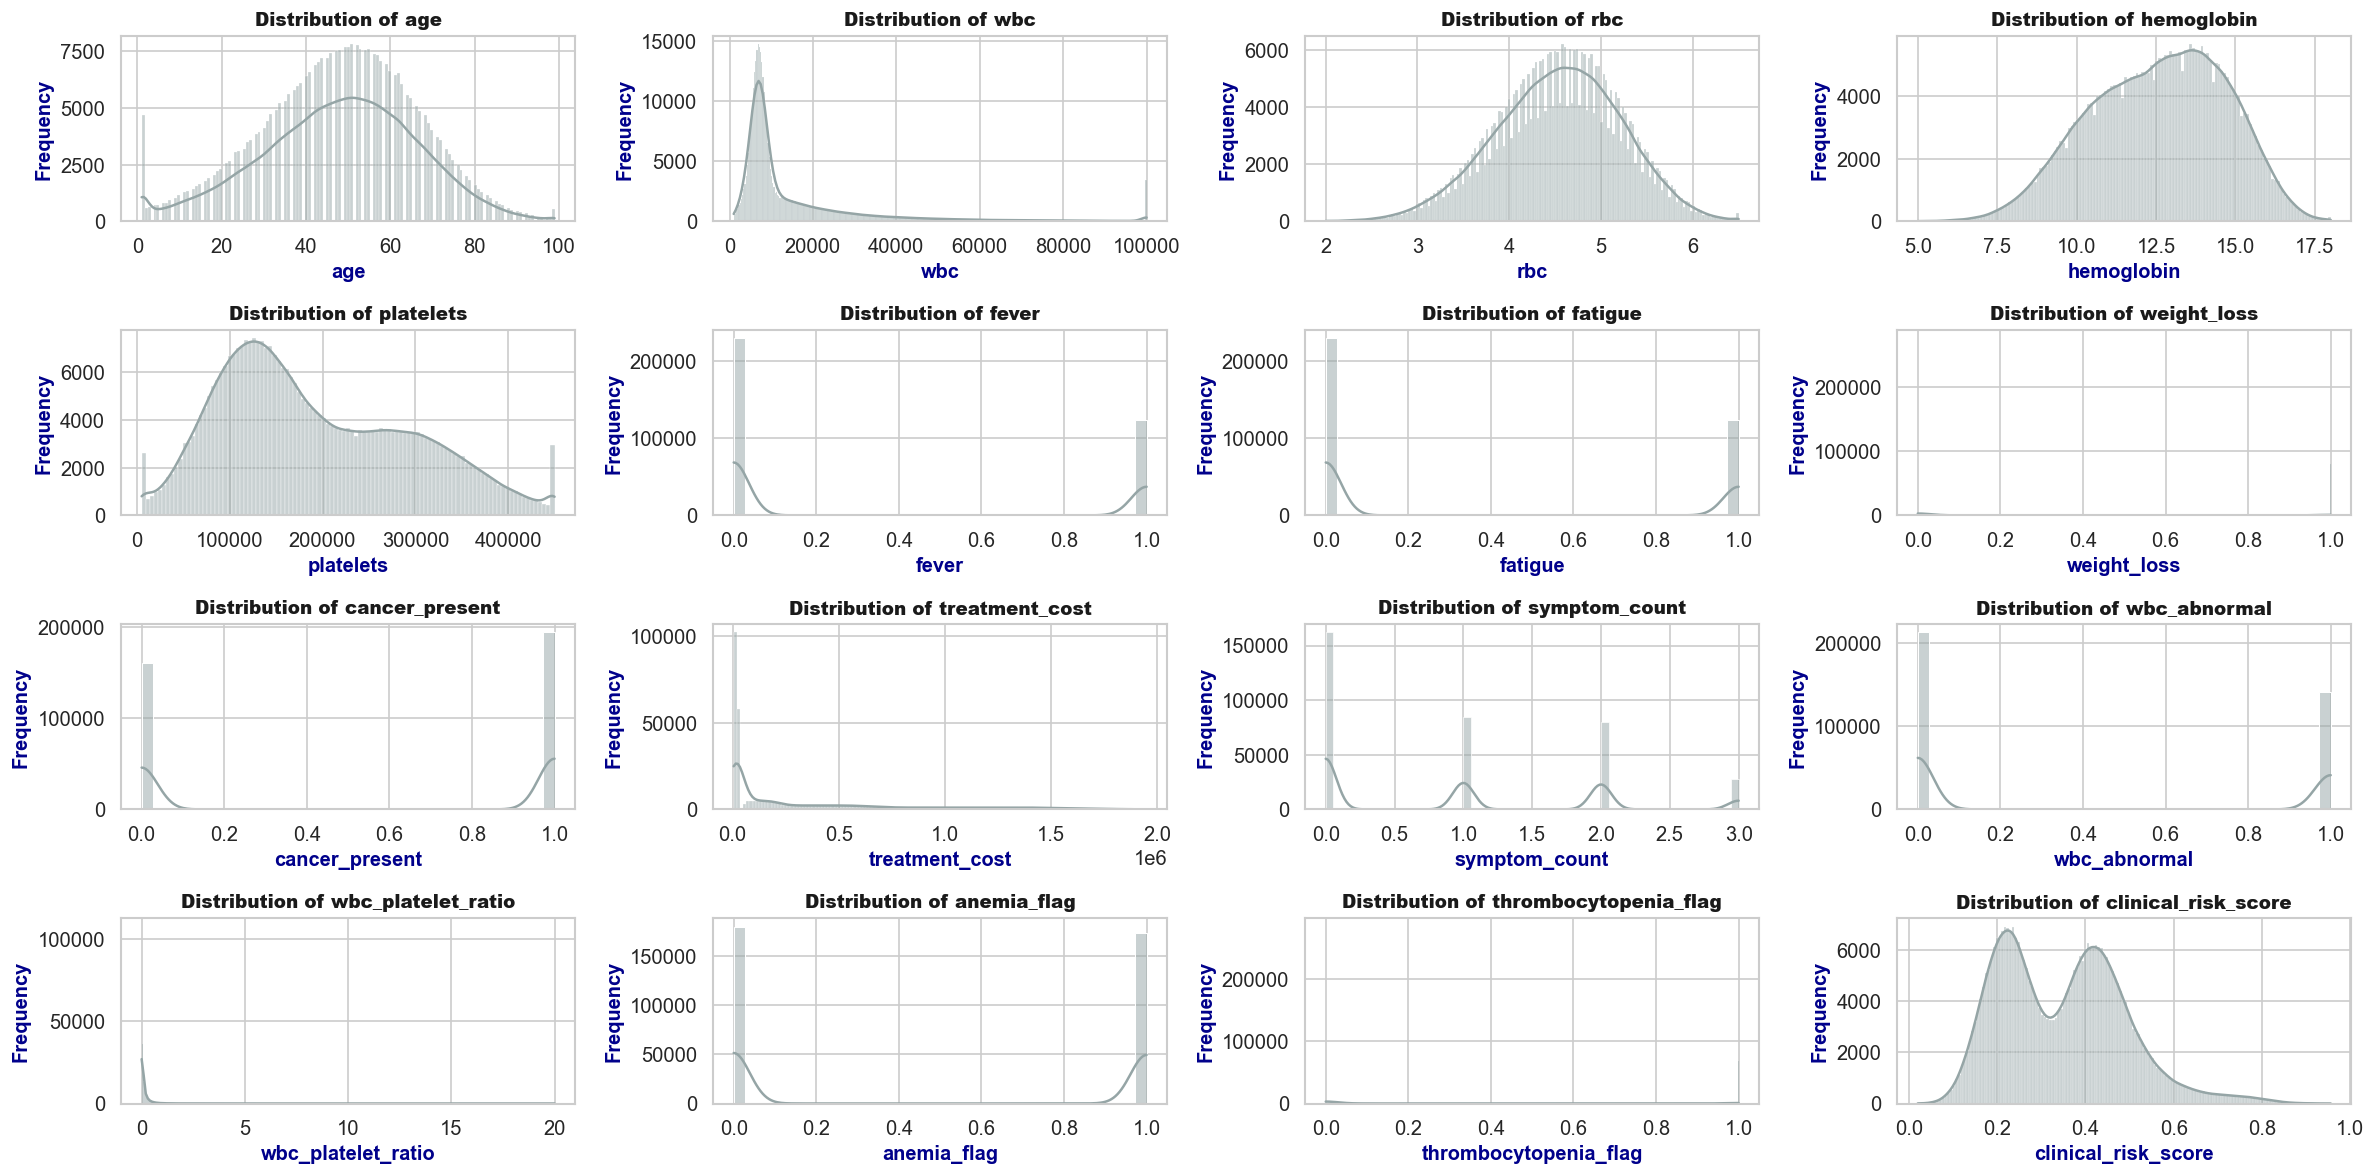

In [24]:
# Numerical Feature Distribution
num_cols_visual = [col for col in num_cols_df_eda if col != "city_tier"]
plt.figure(figsize=(20, 10))
for i, col in enumerate(num_cols_visual, 1):
    plt.subplot(4,4, i)     
    sns.histplot(df_eng[col], kde=True, color='#95a5a6')
    
    plt.title(f"Distribution of {col}", fontsize=11, color="k", fontweight="heavy")
    plt.xlabel(col, fontsize=12, color="darkblue", fontweight="bold")
    plt.ylabel("Frequency", fontsize=12, color="darkblue", fontweight="bold")
    
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Numerical Feature Distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

#### **Insights**

* **Age, RBC, hemoglobin** - roughly normal distribution (good for modeling).
* **WBC, treatment_cost, wbc_platelet_ratio** - highly **right-skewed with outliers**.
* **Platelets** - moderately skewed, multi-range variation.
* **Binary features (fever, fatigue, flags)** - clearly **imbalanced (0 dominates)**.
* **symptom_count** - majority have **0–1 symptoms**, fewer with multiple symptoms.
* **clinical_risk_score** - fairly smooth distribution, good composite signal.

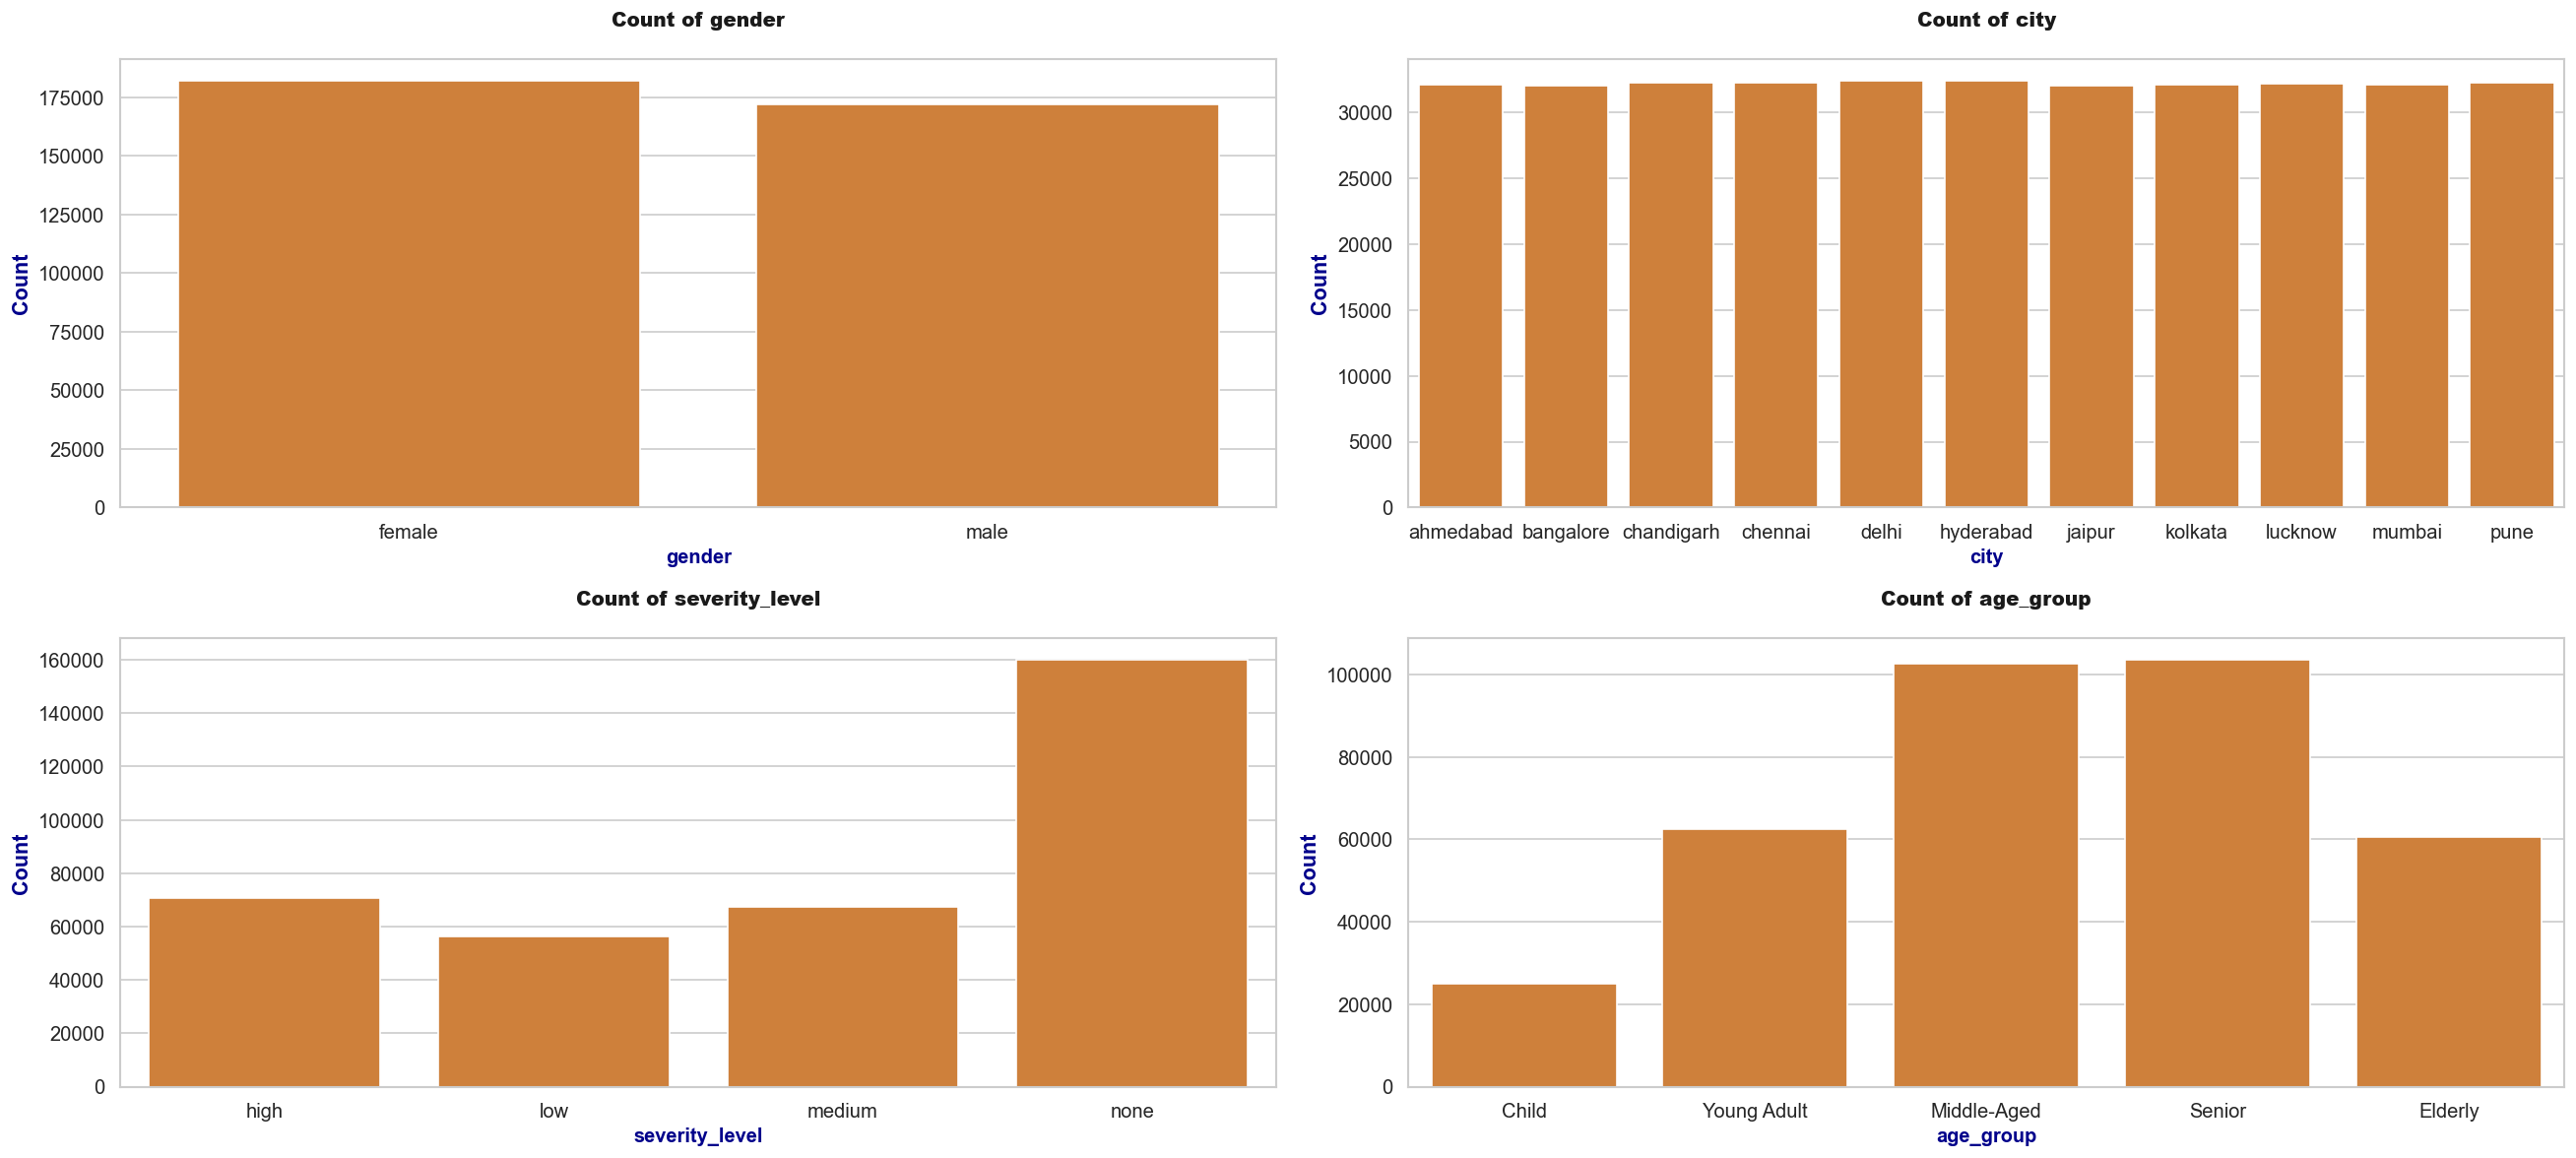

In [26]:
# Categorical Feature Distribution
plt.figure(figsize=(22, 10))
for i, col in enumerate(cat_cols_df_eda, 1):
    plt.subplot(2, 2, i)   
    sns.countplot(x=df_eng[col], color='#e67e22')
    
    plt.title(f"Count of {col}", fontsize=12, color="k", fontweight="heavy", pad=20)
    plt.xlabel(col, fontsize=12, color="darkblue", fontweight="bold")
    plt.ylabel("Count", fontsize=13, color="darkblue", fontweight="bold")
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Categorical Feature Distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

#### **Insights:**

* **Gender**  Nearly balanced (slight female majority).
* **City** - Uniform distribution across all cities (no location bias).
* **Severity** - “None” dominates; among cases, high ≈ medium > low.
* **Age Group** - Majority are **Middle-aged & Senior**, fewer children.

### **Bivariate Analysis**

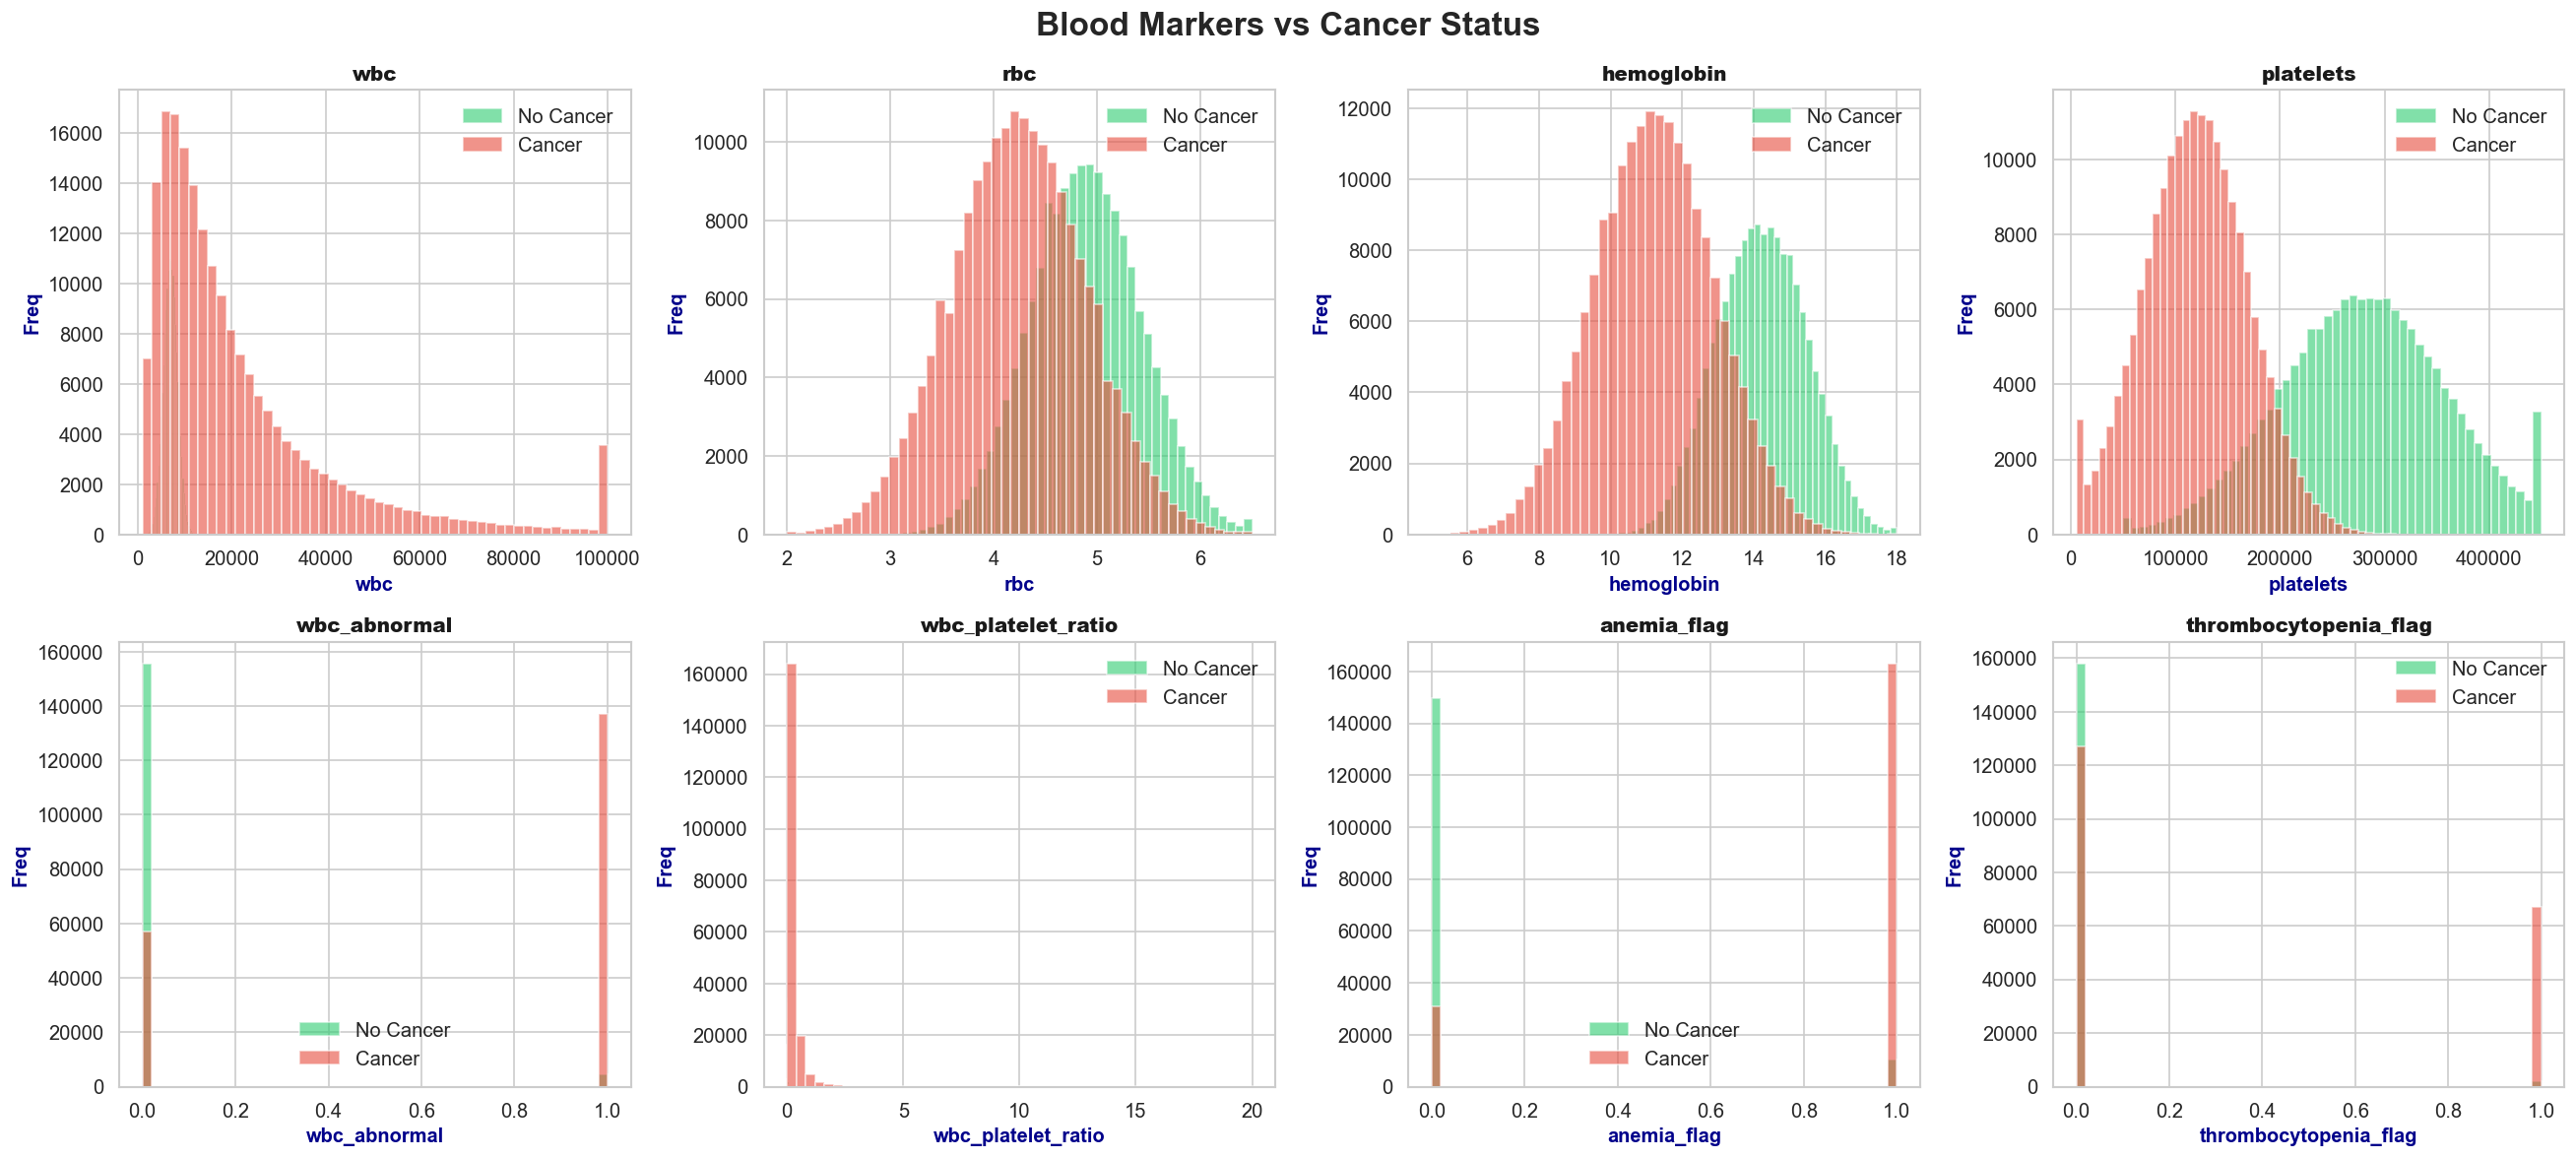

In [27]:
#  Blood Markers vs Cancer Status
blood_cols = [
    "wbc", "rbc", "hemoglobin", "platelets",
    "wbc_abnormal", "wbc_platelet_ratio",
    "anemia_flag", "thrombocytopenia_flag"]

plt.figure(figsize=(22, 10))

for i, col in enumerate(blood_cols, 1):
    
    plt.subplot(2,4, i)     
    # Filter data
    no_cancer = df_eng[df_eng["cancer_present"] == 0][col]
    cancer = df_eng[df_eng["cancer_present"] == 1][col]

    plt.hist(no_cancer, bins=50, alpha=0.6, label='No Cancer', color='#2ecc71')
    plt.hist(cancer, bins=50, alpha=0.6, label='Cancer', color='#e74c3c')
 
    plt.title(col, fontsize=12, color="k", fontweight="heavy")
    plt.xlabel(col, fontsize=12, color="darkblue", fontweight="bold")
    plt.ylabel("Freq", fontsize=12, color="darkblue", fontweight="bold")
    plt.legend()

plt.suptitle("Blood Markers vs Cancer Status", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Blood_Markers_Distribution.png",
    dpi=300, bbox_inches="tight")
plt.show()

#### **Insights**

* **Clear separation** between cancer vs non-cancer using blood markers.
* **High WBC + low RBC, hemoglobin, platelets - strong cancer signal**.
* **Engineered flags perfectly align with cancer cases - high predictive power**.
* Features show **strong discriminative ability**, suitable for high-accuracy models.

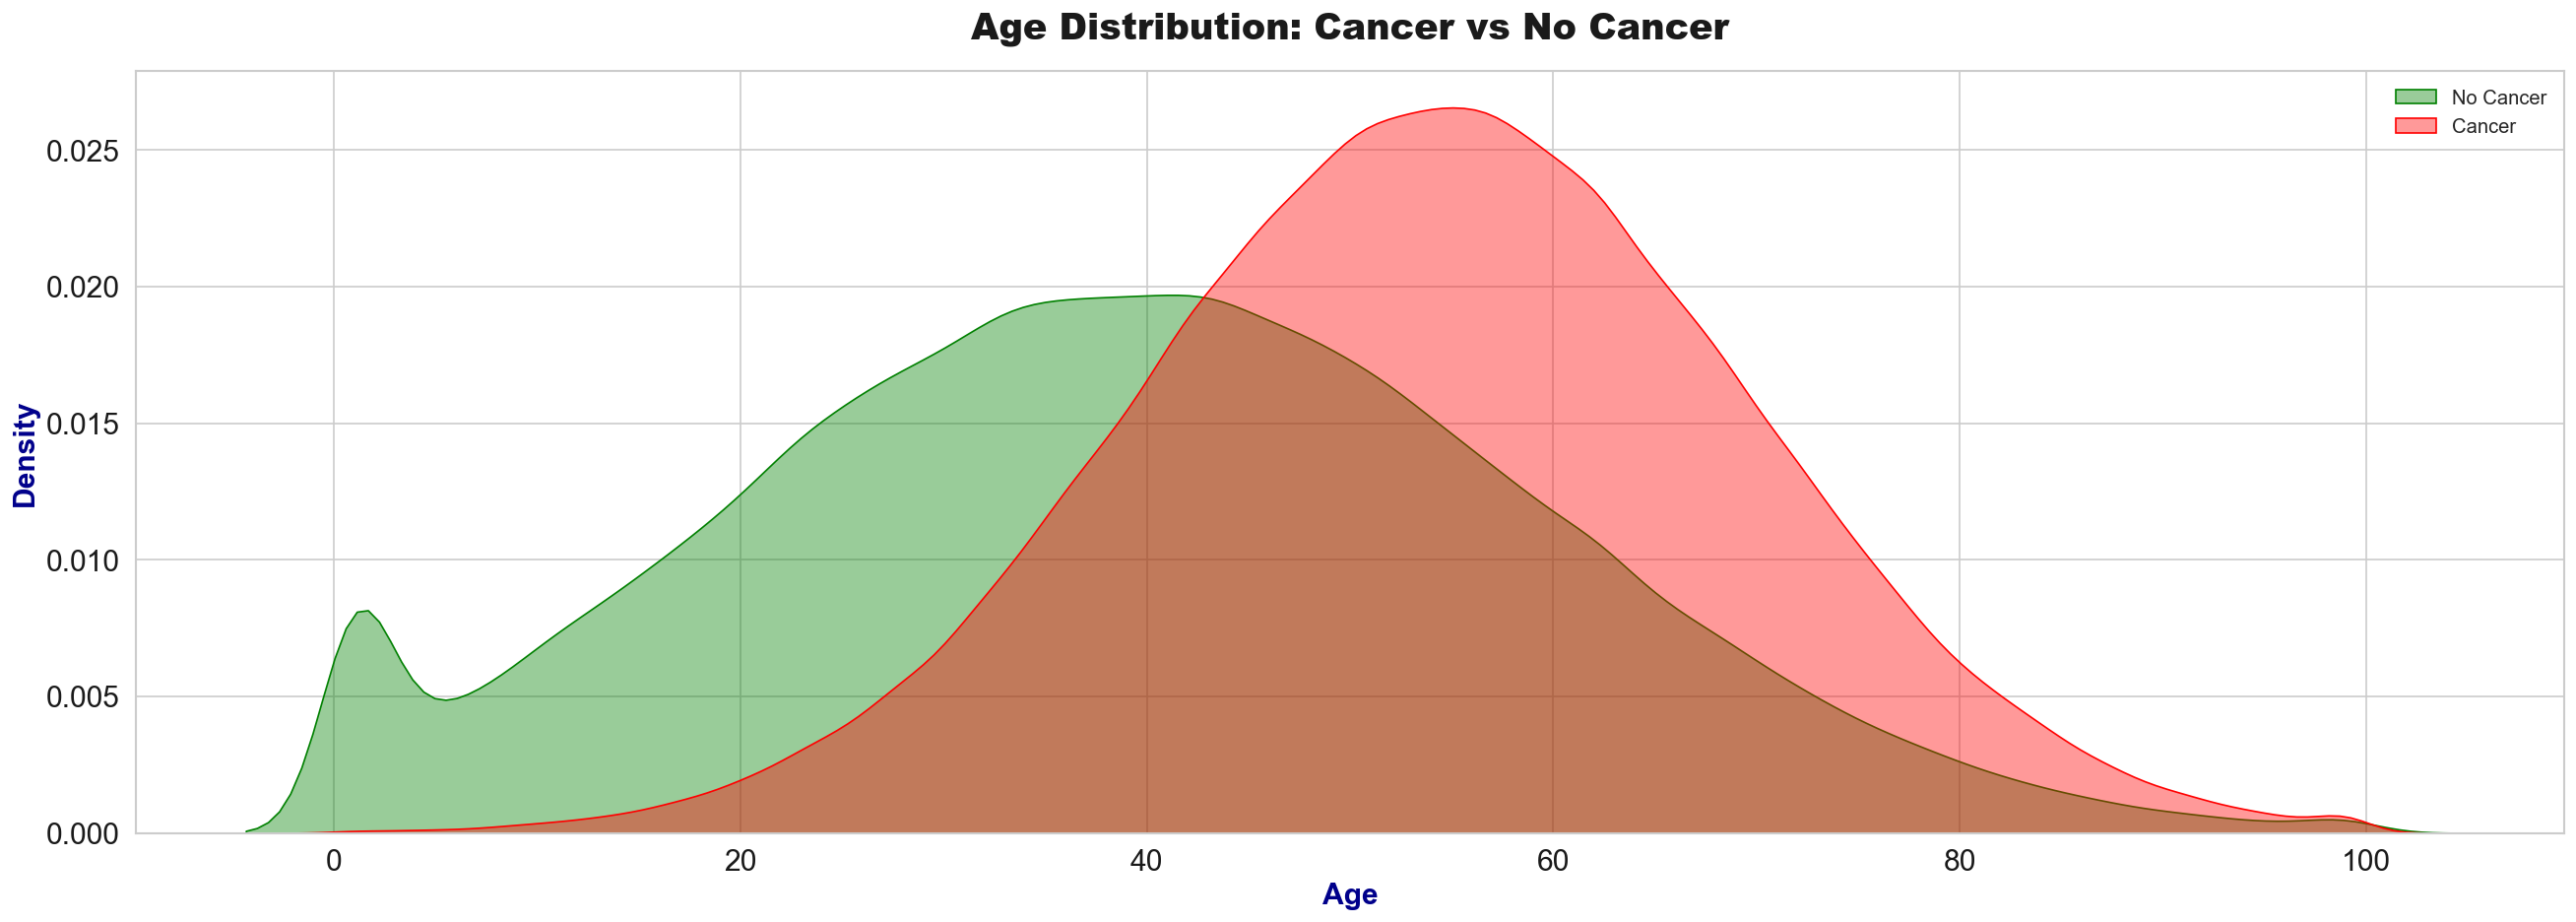

In [ ]:
# Age distribution by cancer presence
plt.figure(figsize=(22, 8))
sns.kdeplot(data=df_eng[df_eng["cancer_present"] == 0]["age"], label='No Cancer', color='green', fill=True, alpha=0.4)
sns.kdeplot(data=df_eng[df_eng["cancer_present"] == 1]["age"], label='Cancer', color='red', fill=True, alpha=0.4)
    
plt.title(f"Age Distribution: Cancer vs No Cancer", fontsize=22, color="k", fontweight="heavy", pad=20)
plt.xlabel("Age", fontsize=18, color="darkblue", fontweight="bold")
plt.ylabel("Density", fontsize=18, color="darkblue", fontweight="bold")
plt.xticks(fontsize=18, color="k")
plt.yticks(fontsize=18, color="k")
plt.legend()
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Age distribution by cancer presence.png",
            dpi=300, bbox_inches="tight")
plt.show()

#### **Insights**

* Cancer cases are **shifted toward older ages** (peak ~50–60).
* Non-cancer cases are **more spread in younger to middle ages**.
* **Age is a strong risk factor**, with probability increasing as age increases.

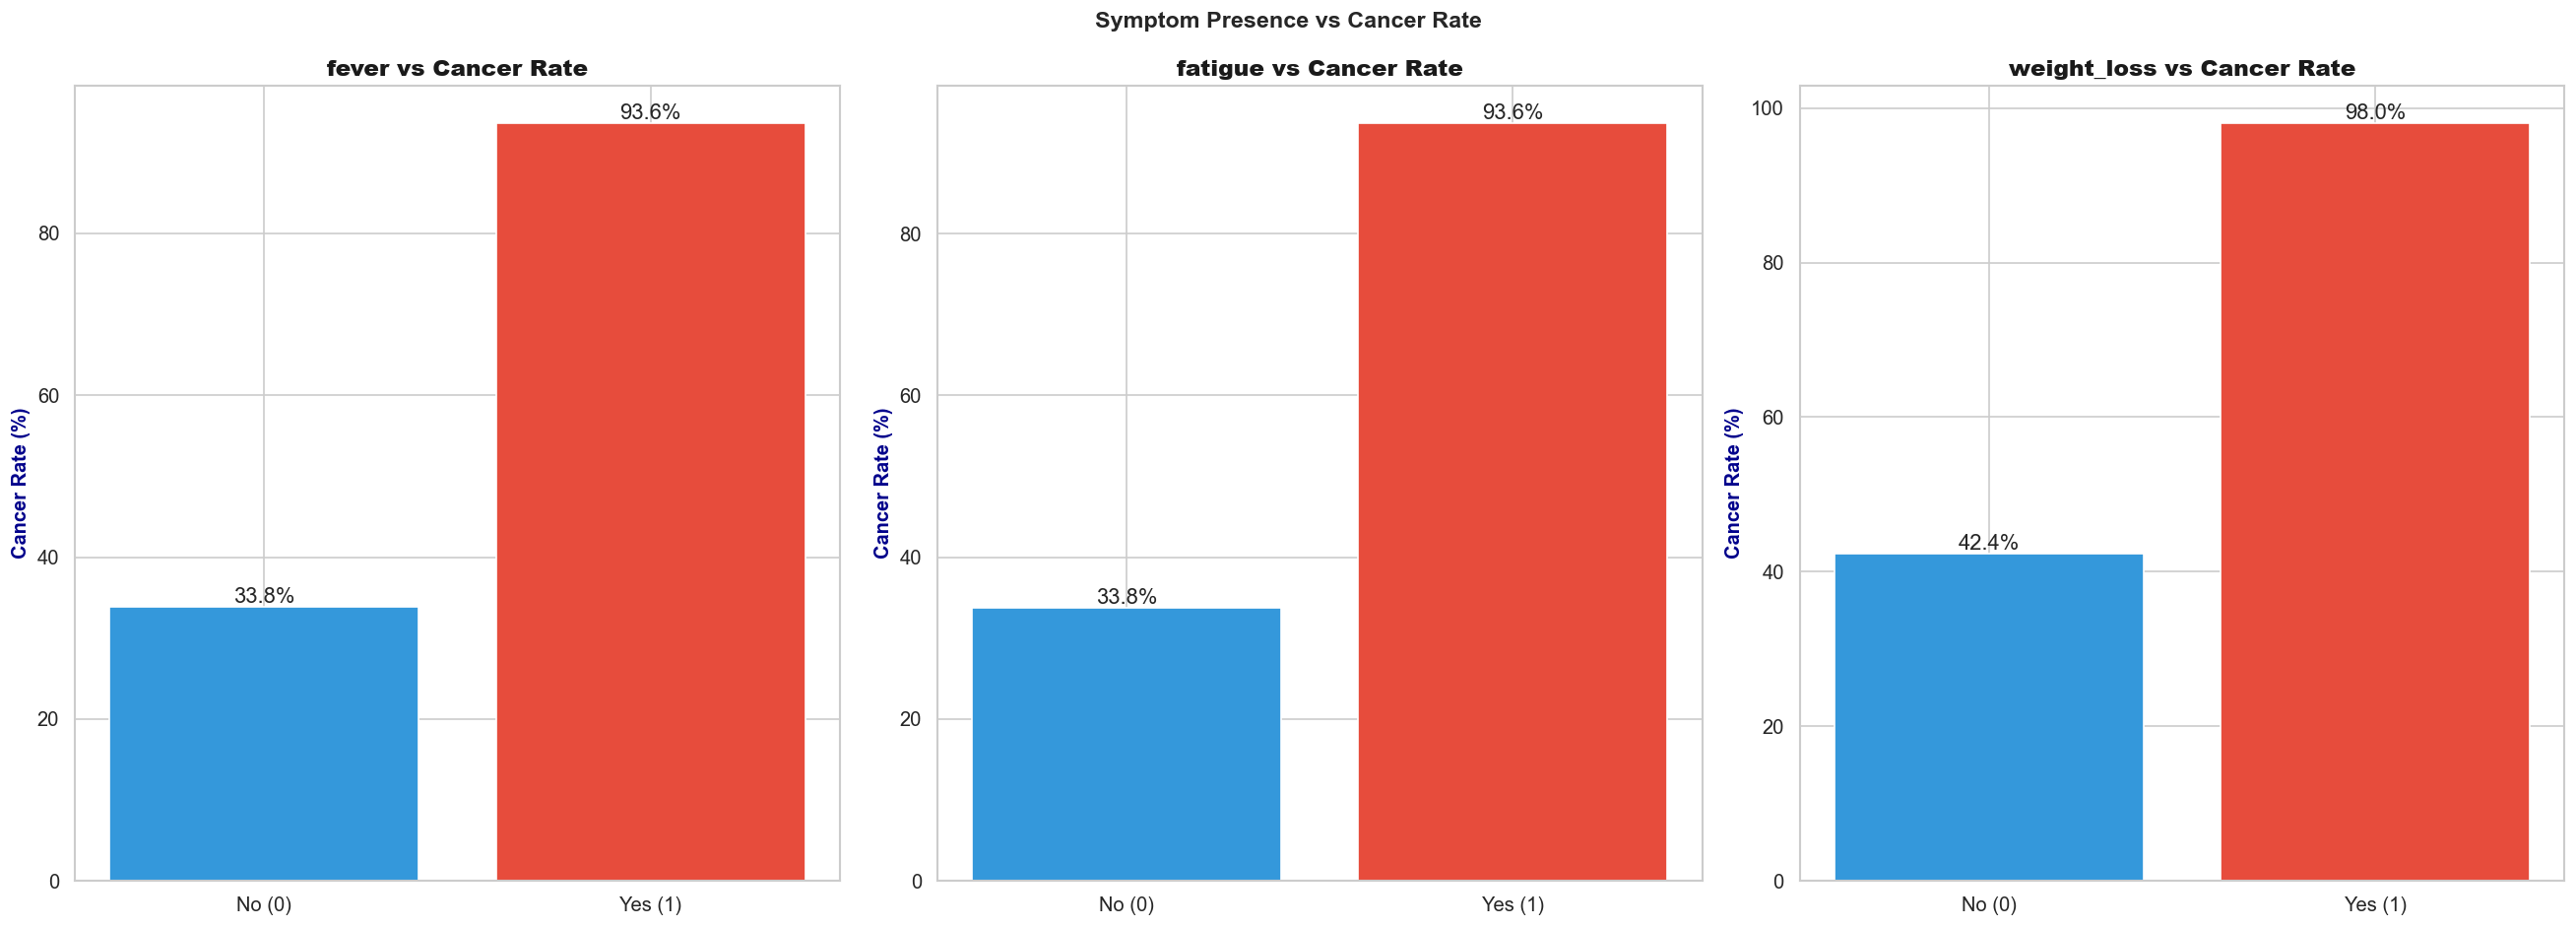

In [ ]:
# Symptom Presence vs Cancer Rate
symptoms = ['fever', 'fatigue', 'weight_loss']
plt.figure(figsize=(22, 8))
for i, sym in enumerate(symptoms, 1):
    
    plt.subplot(1, 3, i) 
    cancer_rate = df_eng.groupby(sym)["cancer_present"].mean() * 100
    
    plt.bar(['No (0)', 'Yes (1)'], cancer_rate.values, color=['#3498db', '#e74c3c'])
    
    plt.title(f"{sym} vs Cancer Rate",fontsize=14, color="k", fontweight="heavy")
    plt.ylabel("Cancer Rate (%)", fontsize=12, color="darkblue", fontweight="bold")

    for j, val in enumerate(cancer_rate.values):
        plt.text(j, val, f"{val:.1f}%", ha='center', va='bottom')

plt.suptitle("Symptom Presence vs Cancer Rate", fontsize=14, fontweight='bold')
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Symptom Presence vs Cancer Rate.png",
    dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

#### **Insights**

* Presence of symptoms **drastically increases cancer probability**.
* **Fever & fatigue** - ~34% (No) - ~94% (Yes).
* **Weight loss** - strongest signal (~42% - ~98%).
* Symptoms are **highly predictive features for classification**.

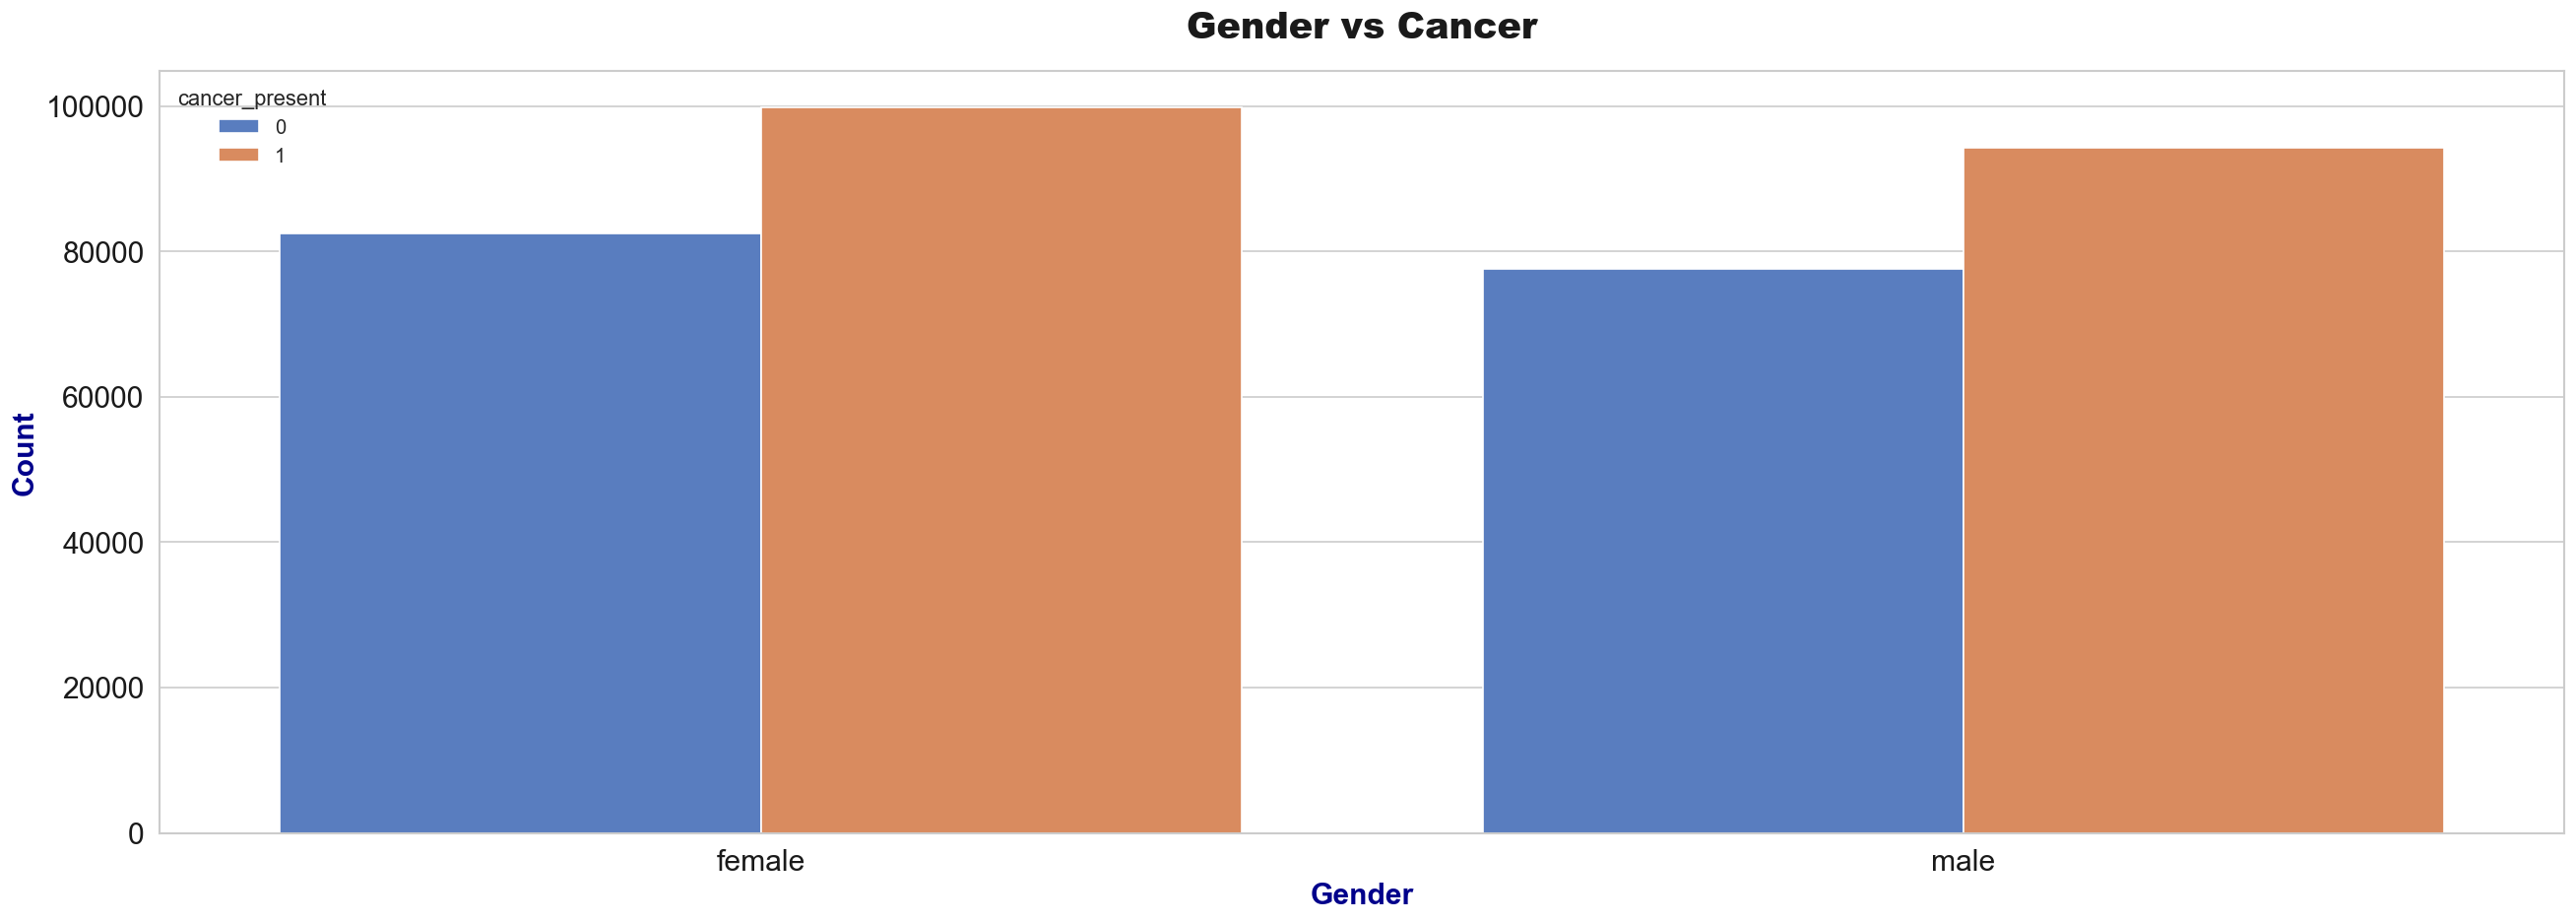

In [ ]:
# Cancer vs Gender
plt.figure(figsize=(22, 8))
sns.countplot(x="gender", hue="cancer_present", data=df_eng)
    
plt.title(f"Gender vs Cancer", fontsize=22, color="k", fontweight="heavy", pad=20)
plt.xlabel("Gender", fontsize=18, color="darkblue", fontweight="bold")
plt.ylabel("Count", fontsize=18, color="darkblue", fontweight="bold")
plt.xticks(fontsize=18, color="k")
plt.yticks(fontsize=18, color="k")
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Cancer vs Gender.png",
            dpi=300, bbox_inches="tight")
plt.show()

#### **Insights**

* Cancer cases are **slightly higher in females than males**, but difference is small.
* Both genders show **similar distribution patterns**.
* **Gender is a weak predictor** compared to clinical features.

In [ ]:
# Count + Percentage together
count = df_eng.groupby(['gender', 'cancer_present']).size().unstack(fill_value=0)
percent = df_eng.groupby('gender')['cancer_present'].value_counts(normalize=True).mul(100).round(2).unstack()

final = count.astype(str) + " (" + percent.astype(str) + "%)"
print(final)

cancer_present               0               1
gender                                        
female          82418 (45.21%)  99870 (54.79%)
male            77661 (45.19%)  94207 (54.81%)


#### **Insights**

* Cancer rate is **almost identical across genders (~54.8%)**.
* No meaningful difference between male and female.
* **Gender has negligible predictive power**.


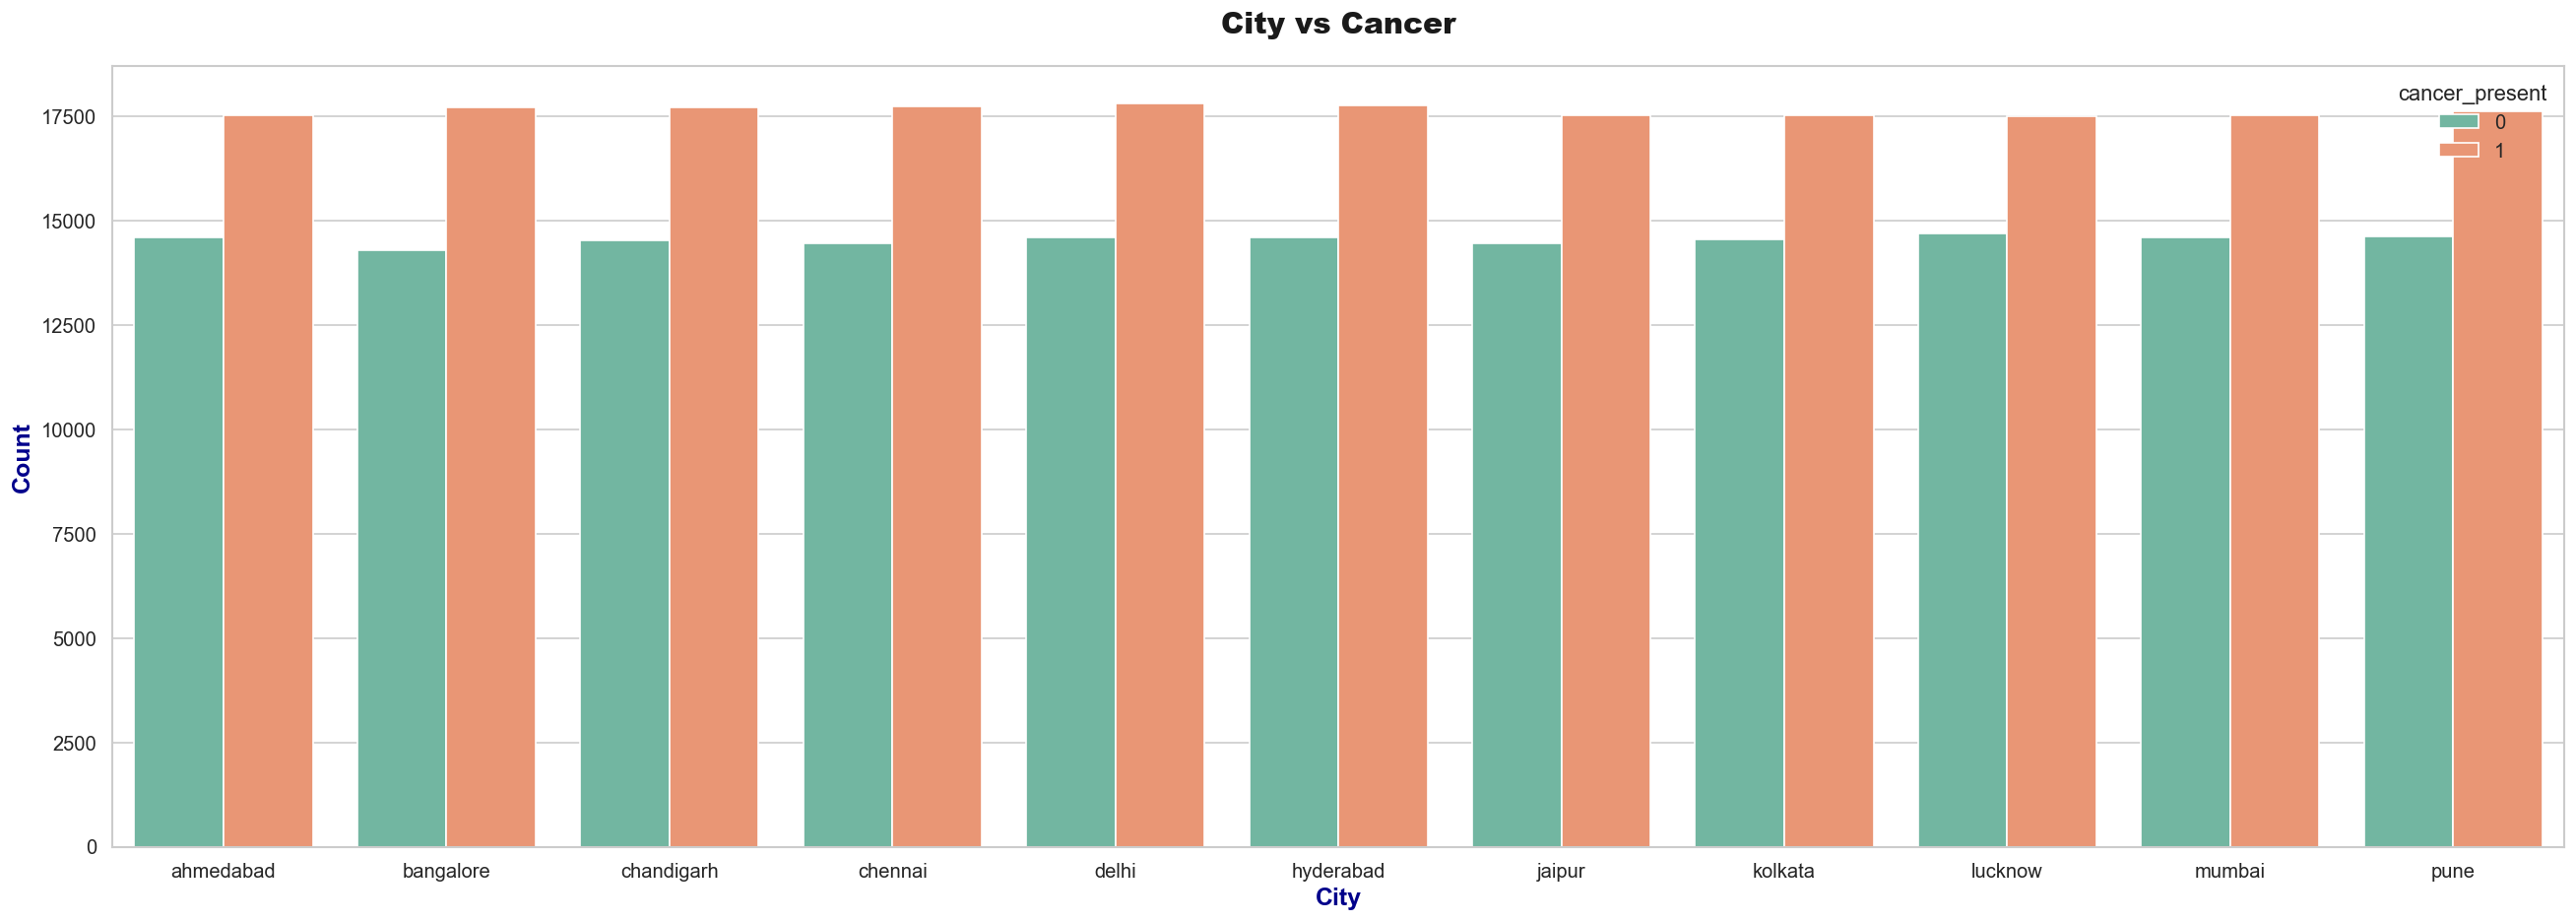

In [ ]:
# Cancer vs City 
plt.figure(figsize=(22, 8))
sns.countplot(x="city", hue="cancer_present", data=df_eng, palette="Set2")
    
plt.title(f"City vs Cancer", fontsize=18, color="k", fontweight="heavy", pad=20)
plt.xlabel("City", fontsize=15, color="darkblue", fontweight="bold")
plt.ylabel("Count", fontsize=15, color="darkblue", fontweight="bold")
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Cancer vs City.png",
            dpi=300, bbox_inches="tight")
plt.show()

#### **Insights**

* Cancer distribution is **uniform across all cities**.
* No city shows significantly higher or lower cancer cases.
* **City has low predictive power** for cancer detection (useful mainly for cost modeling).

### **Multivariate Analysis**

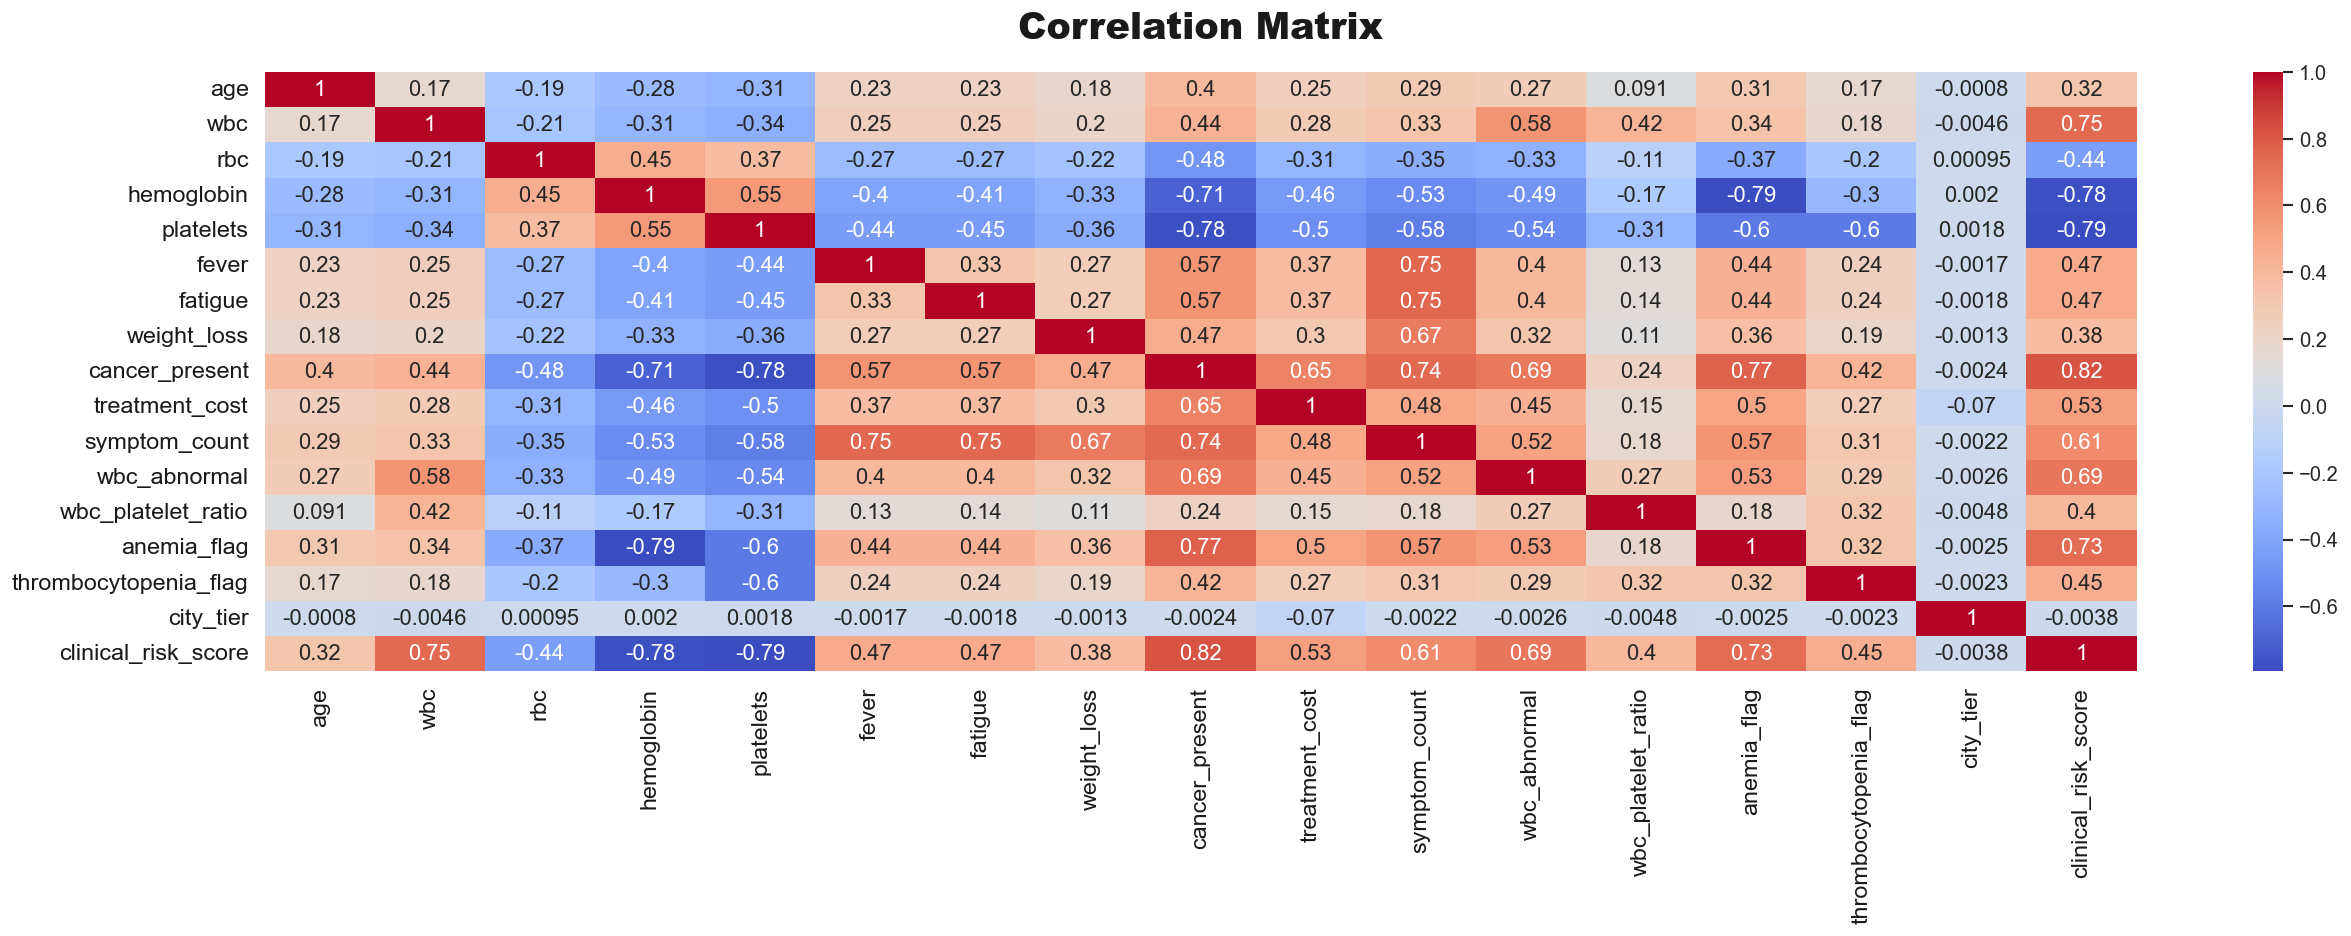

In [ ]:
# Correlation matrix (Heatmap)
plt.figure(figsize=(22,8))
correlation = df_eng.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix", fontsize=22, color="k", fontweight="heavy",pad=20)
plt.xticks(fontsize=14, color="k")
plt.yticks(fontsize=14, color="k")
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Correlation Heatmap.png",
            dpi=300, bbox_inches="tight")
plt.show()

#### **Insights**

* **Strong positive predictors** - clinical_risk_score (0.82), anemia_flag (0.77), symptom_count (0.74), wbc_abnormal (0.69).
* **Strong negative predictors** - hemoglobin (-0.71), platelets (-0.78), rbc (-0.48).
* **WBC moderately positive (0.44)** - supports cancer detection.
* **City tier has no correlation (~0)** - not useful for detection.
* Features show **clear medical relationships - strong model signals**.


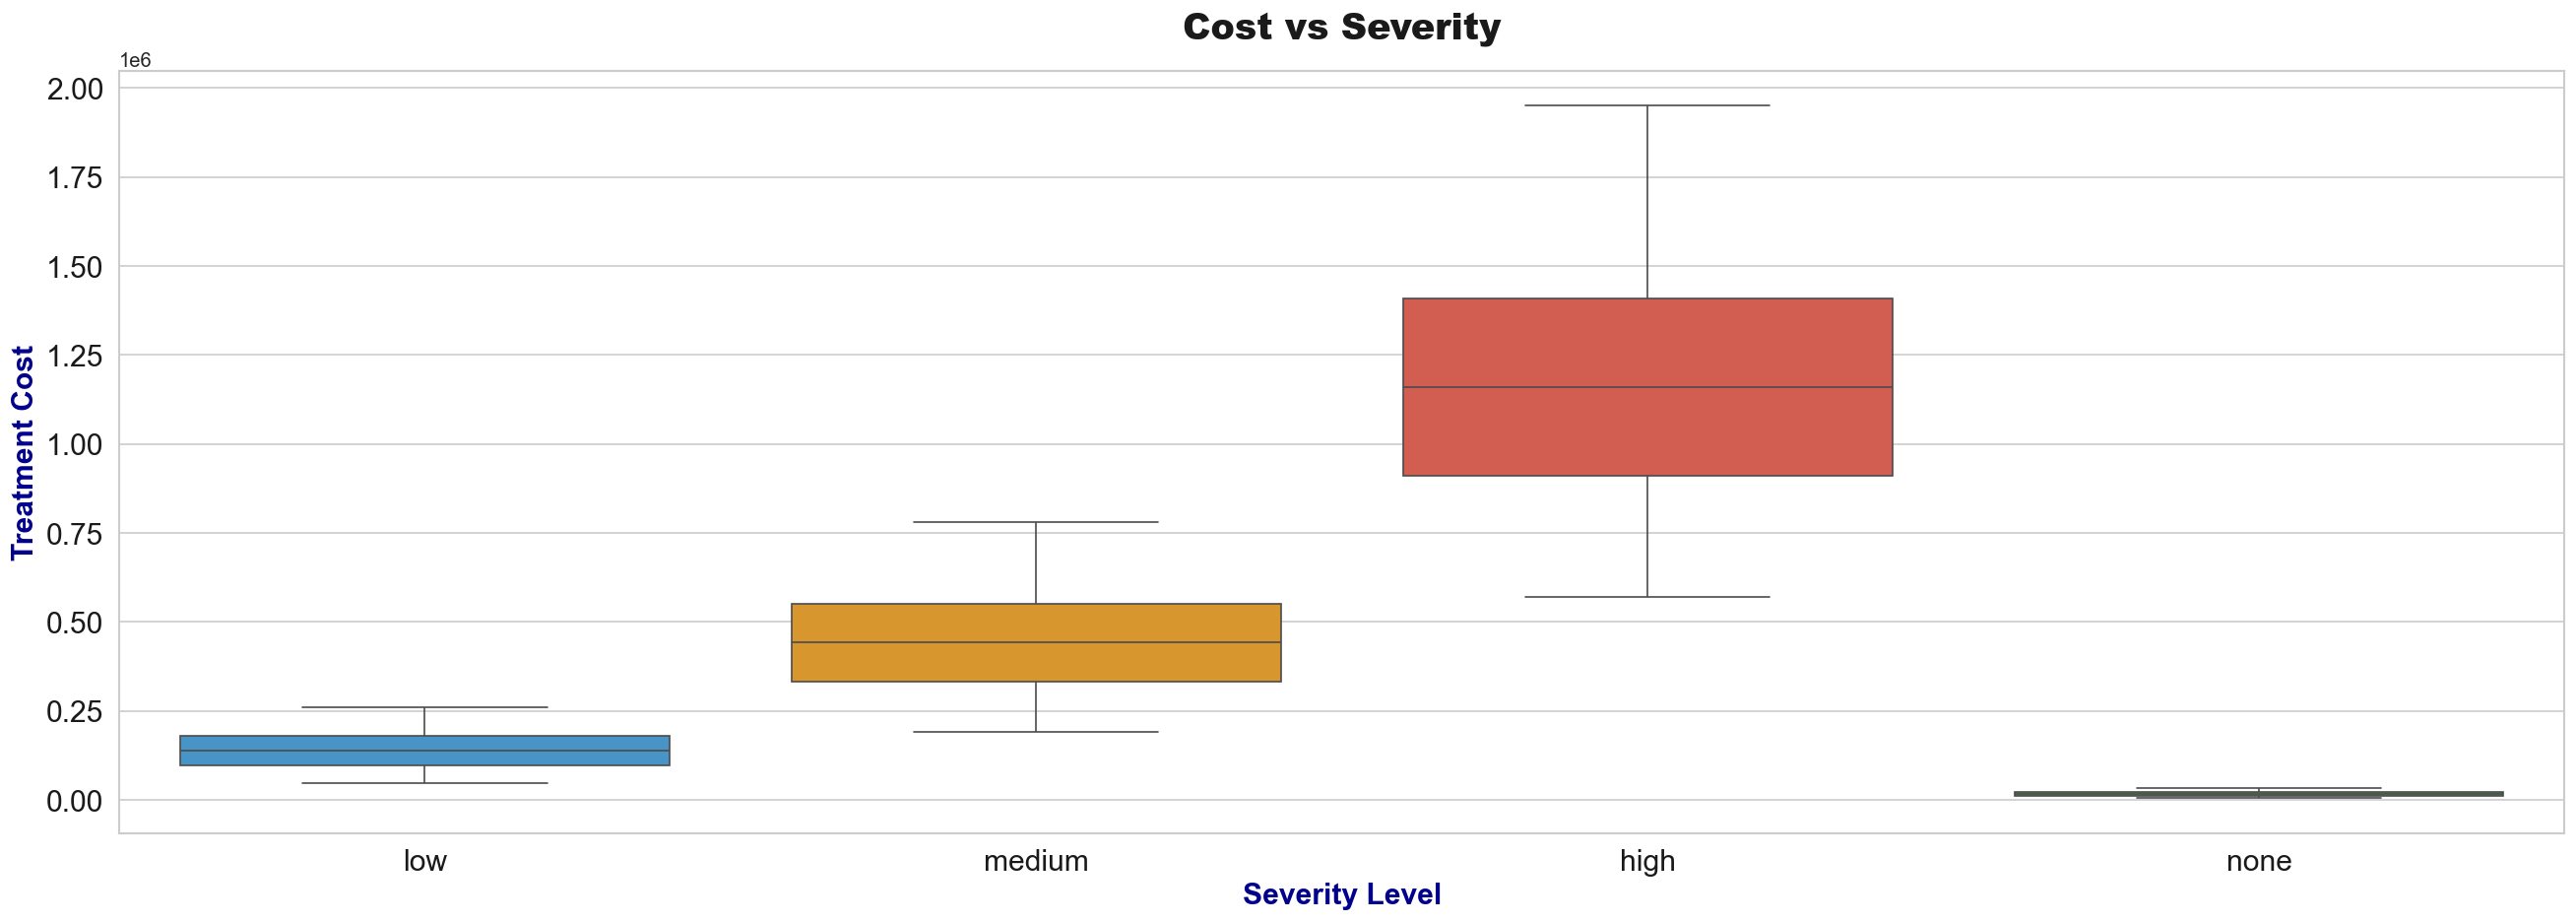

In [ ]:
# Cost Analysis
plt.figure(figsize=(22,8))
severity_order = ['low', 'medium', 'high', 'none']
sns.boxplot(x="severity_level", y="treatment_cost", data=df_eng,   order=severity_order, 
            palette=['#3498DB', '#F39C12', '#E74C3C', '#4CAF50'])

plt.title("Cost vs Severity", fontsize=22, color="k", fontweight="heavy", pad=20)
plt.xlabel("Severity Level", fontsize=18, color="darkblue", fontweight="bold")
plt.ylabel("Treatment Cost", fontsize=18, color="darkblue", fontweight="bold")
plt.xticks(fontsize=18, color="k")
plt.yticks(fontsize=18, color="k")
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Cost Analysis.png",
            dpi=300, bbox_inches="tight")
plt.show()

#### **Insights**

* **Treatment cost increases with severity** (low < medium < high).
* **High severity has highest cost and variability**.
* **No cancer (“none”) has minimal cost**.
* Severity is a **strong predictor for cost modeling**.


tier_label           Tier-1       Tier-2       Tier-3
severity_level                                       
high           1311150.3000 1181755.6600 1044968.0800
low             155930.9400  140666.4700  125906.1300
medium          498542.5300  449552.3050  399984.0150


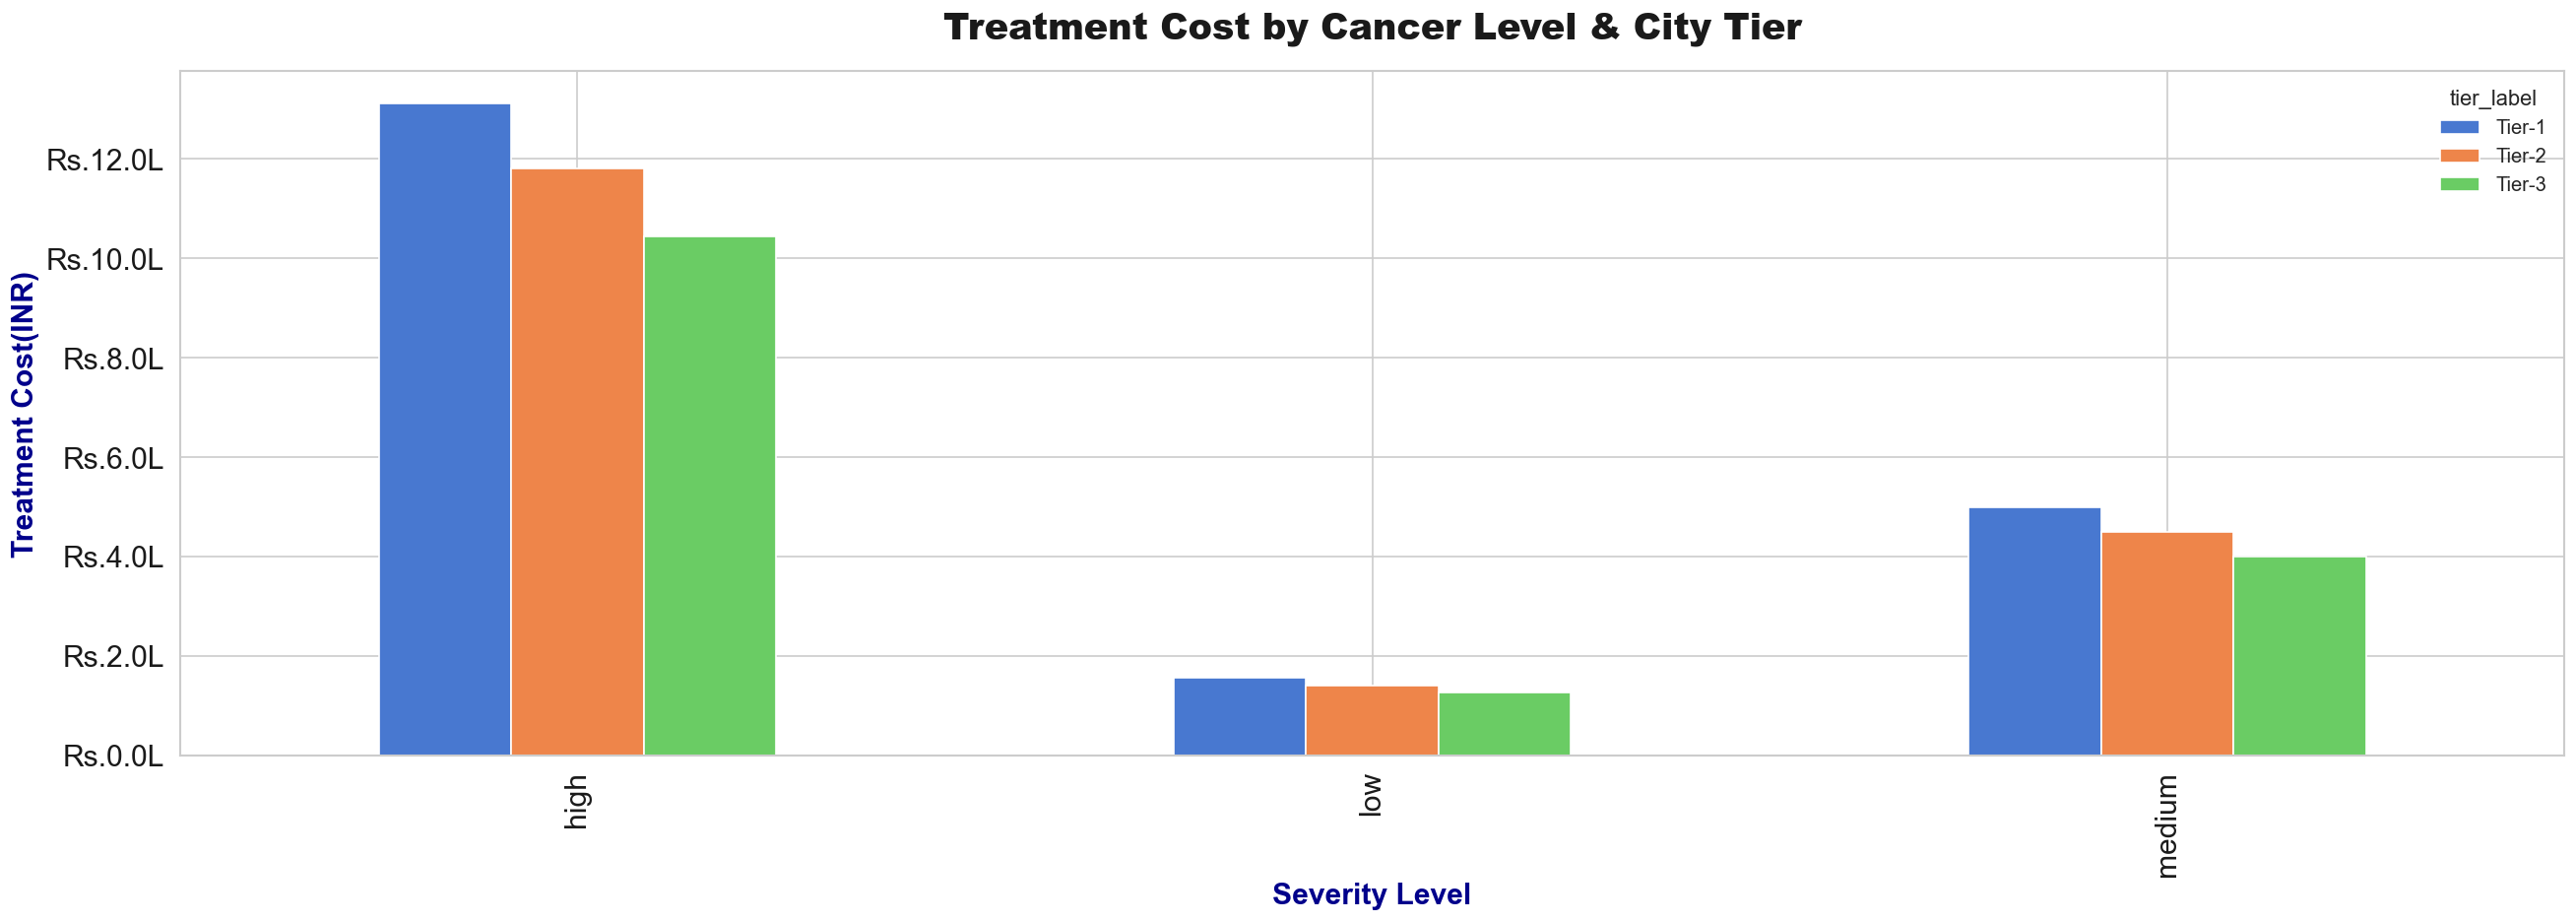

In [ ]:
# Median Treatment Cost by Cancer Level & City Tier
cancer_df = df_eng[df_eng["cancer_present"] == 1].copy()

# Create tier label 
tier_map_label = {1:'Tier-1', 2:'Tier-2', 3:'Tier-3'}
cancer_df["tier_label"] = cancer_df["city_tier"].map(tier_map_label)

cancer_df = cancer_df.dropna(subset=['severity_level', 'tier_label', 'treatment_cost'])
pivot = cancer_df.groupby(['severity_level','tier_label'])['treatment_cost'].median().unstack()

print(pivot) 

# Plot
if not pivot.empty:
    pivot.plot(kind='bar', figsize=(22,8))
    
    plt.gca().yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'Rs.{x/1e5:.1f}L'))
    plt.title("Treatment Cost by Cancer Level & City Tier", fontsize=22, color="k", fontweight="heavy", pad=20)
    plt.xlabel("Severity Level", fontsize=18, color="darkblue", fontweight="bold")
    plt.ylabel("Treatment Cost(INR)", fontsize=18, color="darkblue", fontweight="bold")
    plt.xticks(fontsize=18, color="k")
    plt.yticks(fontsize=18, color="k")
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Median Treatment Cost by Cancer Level & City Tier.png",
            dpi=300, bbox_inches="tight")
plt.show()

#### **Insights**

* **Cost increases with severity** across all city tiers.
* **Tier-1 cities have highest cost**, followed by Tier-2, then Tier-3.
* Cost differences are **consistent across severity levels**.
* Both **severity + city tier strongly influence treatment cost**.


## **Final checking of dataset**
---

In [ ]:
df_eng.sample(10)

,age,gender,wbc,rbc,hemoglobin,platelets,fever,fatigue,weight_loss,city,cancer_present,severity_level,treatment_cost,symptom_count,wbc_abnormal,wbc_platelet_ratio,anemia_flag,thrombocytopenia_flag,city_tier,clinical_risk_score,age_group
239379,28,male,7507,6.1200,13.8400,446013,0,0,0,lucknow,0,none,6411.5900,0,0,0.0168,0,0,3,0.1405,Young Adult
325959,60,female,7496,4.9100,13.7600,217872,0,0,0,lucknow,0,none,11833.0500,0,0,0.0344,0,0,3,0.2708,Senior
296515,70,female,5159,4.7100,12.7700,274185,0,0,0,ahmedabad,0,none,12062.9200,0,0,0.0188,0,0,3,0.2564,Elderly
10498,73,male,29663,4.8400,9.9700,198568,0,0,1,chennai,1,medium,533829.3100,1,1,0.1494,1,0,2,0.4733,Elderly
71962,38,female,1551,2.9800,10.3400,48551,1,1,0,chandigarh,1,high,1188001.9000,2,1,0.0319,1,1,3,0.4340,Middle-Aged
249869,40,male,5363,5.5000,15.1300,337891,0,0,0,lucknow,0,none,17437.9800,0,0,0.0159,0,0,3,0.1579,Middle-Aged
271223,42,male,5988,6.0500,13.8400,146331,0,0,0,kolkata,0,none,11281.0100,0,0,0.0409,0,0,2,0.3028,Middle-Aged
234170,40,female,3870,4.4200,12.9800,450000,0,0,0,chennai,0,none,7690.9100,0,1,0.0086,0,0,2,0.1467,Middle-Aged
88240,37,female,12517,3.3300,13.3500,132242,0,0,0,pune,1,high,1295121.5600,0,1,0.0947,0,0,2,0.3502,Middle-Aged
251937,52,female,5871,4.6300,13.1600,237816,0,0,0,chennai,0,none,24591.7600,0,0,0.0247,0,0,2,0.2692,Senior


In [ ]:
# Check unique values for each column
print(f"Unique value counts per column:\n")
for col in df_eng.columns:
    print(f"Unique values in {col}: {df_eng[col].nunique()}")

Unique value counts per column:

Unique values in age: 99
Unique values in gender: 2
Unique values in wbc: 53964
Unique values in rbc: 451
Unique values in hemoglobin: 1262
Unique values in platelets: 221746
Unique values in fever: 2
Unique values in fatigue: 2
Unique values in weight_loss: 2
Unique values in city: 11
Unique values in cancer_present: 2
Unique values in severity_level: 4
Unique values in treatment_cost: 348657
Unique values in symptom_count: 4
Unique values in wbc_abnormal: 2
Unique values in wbc_platelet_ratio: 353447
Unique values in anemia_flag: 2
Unique values in thrombocytopenia_flag: 2
Unique values in city_tier: 3
Unique values in clinical_risk_score: 8046
Unique values in age_group: 5


#### **Observation**

* Dataset has **high cardinality in numerical features** (wbc, platelets, treatment_cost).
* **Categorical features are low and well-defined** (gender, city, severity).
* Mix of **binary, categorical, and continuous variables** - suitable for ML.
* Engineered features are **controlled and meaningful (low unique values where expected)**.


In [ ]:
# Drop irrelevant Columns 
print("Before shape:", df_eng.shape)
df_eng.drop(["city_tier", "age_group"], axis=1, inplace=True, errors="ignore")
print("After shape:", df_eng.shape)

Before shape: (354156, 21)
After shape: (354156, 19)


#### **Observation**

* **2 features removed**, dataset reduced from 21 - 19 columns.
* **Row count unchanged** - no data loss.
* Feature reduction done without affecting dataset size.


In [ ]:
df_eng.dtypes

age                         int16
gender                   category
wbc                         int64
rbc                       float64
hemoglobin                float64
platelets                   int64
fever                        int8
fatigue                      int8
weight_loss                  int8
city                     category
cancer_present               int8
severity_level           category
treatment_cost            float64
symptom_count               int64
wbc_abnormal                int64
wbc_platelet_ratio        float64
anemia_flag                 int64
thrombocytopenia_flag       int64
clinical_risk_score       float64
dtype: object

In [ ]:
df_eng.isnull().sum()

age                      0
gender                   0
wbc                      0
rbc                      0
hemoglobin               0
platelets                0
fever                    0
fatigue                  0
weight_loss              0
city                     0
cancer_present           0
severity_level           0
treatment_cost           0
symptom_count            0
wbc_abnormal             0
wbc_platelet_ratio       0
anemia_flag              0
thrombocytopenia_flag    0
clinical_risk_score      0
dtype: int64

In [ ]:
# int64 -int8 & float64 - float32
cols_int8 = ["symptom_count", "wbc_abnormal", "anemia_flag", "thrombocytopenia_flag"]
cols_float32 = ["wbc_platelet_ratio", "clinical_risk_score"]

# Handle safely
df_eng[cols_int8] = df_eng[cols_int8].astype("int8")
df_eng[cols_float32] = df_eng[cols_float32].astype("float32")

#### **Observation**

* Dataset has **no missing values** and correct data types.
* Memory optimized by converting **int64 - int8** and **float64 - float32**.
* Data is **clean, efficient, and ready for modeling**.


In [ ]:
# Final checks
print(f"Final Shape of dataset: {df_eng.shape}\n")
print("Columns:\n", df_eng.columns.to_frame(index=False, name="Column Name"))
display(df_eng.head(6))
display(df_eng.info())

# Identify numerical and categorical columns
num_cols_df_eng = df_eng.select_dtypes(include=["int8", "int16", "int64", "float32", "float64",]).columns.tolist()
cat_cols_df_eng = df_eng.select_dtypes(include=["category"]).columns.tolist()

print(f"Numerical columns ({len(num_cols_df_eng)}): {num_cols_df_eng}\n")
print(f"Categorical columns ({len(cat_cols_df_eng)}): {cat_cols_df_eng}")

print(f"\nMissing Values After Cleaning: {df_eng.isnull().sum().any()}")
print(f"Duplicates After Cleaning: {df_eng.duplicated().sum().any()}")

Final Shape of dataset: (354156, 19)

Columns:
               Column Name
0                     age
1                  gender
2                     wbc
3                     rbc
4              hemoglobin
5               platelets
6                   fever
7                 fatigue
8             weight_loss
9                    city
10         cancer_present
11         severity_level
12         treatment_cost
13          symptom_count
14           wbc_abnormal
15     wbc_platelet_ratio
16            anemia_flag
17  thrombocytopenia_flag
18    clinical_risk_score


,age,gender,wbc,rbc,hemoglobin,platelets,fever,fatigue,weight_loss,city,cancer_present,severity_level,treatment_cost,symptom_count,wbc_abnormal,wbc_platelet_ratio,anemia_flag,thrombocytopenia_flag,clinical_risk_score
0,62,female,11483,3.7400,10.9800,220307,0,0,0,chennai,1,high,1491044.5100,0,1,0.0521,1,0,0.3604
1,52,female,15893,3.5900,12.3400,137043,1,1,0,jaipur,1,low,115831.7700,2,1,0.1160,0,0,0.3884
2,64,female,8930,3.8600,11.1900,118447,1,1,1,hyderabad,1,high,1578648.8500,3,0,0.0754,1,0,0.4017
3,77,female,8337,4.4200,8.6400,103390,1,1,1,delhi,1,medium,598684.0100,3,0,0.0806,1,0,0.4764
4,51,male,10374,3.7600,10.9200,196707,1,0,0,chennai,1,medium,273321.5800,1,0,0.0527,1,0,0.3708
5,51,female,3375,4.2200,11.1300,103781,0,0,0,ahmedabad,1,high,1551963.1200,0,1,0.0325,1,0,0.3891


<class 'pandas.DataFrame'>
RangeIndex: 354156 entries, 0 to 354155
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   age                    354156 non-null  int16   
 1   gender                 354156 non-null  category
 2   wbc                    354156 non-null  int64   
 3   rbc                    354156 non-null  float64 
 4   hemoglobin             354156 non-null  float64 
 5   platelets              354156 non-null  int64   
 6   fever                  354156 non-null  int8    
 7   fatigue                354156 non-null  int8    
 8   weight_loss            354156 non-null  int8    
 9   city                   354156 non-null  category
 10  cancer_present         354156 non-null  int8    
 11  severity_level         354156 non-null  category
 12  treatment_cost         354156 non-null  float64 
 13  symptom_count          354156 non-null  int8    
 14  wbc_abnormal           354156 n

None

Numerical columns (16): ['age', 'wbc', 'rbc', 'hemoglobin', 'platelets', 'fever', 'fatigue', 'weight_loss', 'cancer_present', 'treatment_cost', 'symptom_count', 'wbc_abnormal', 'wbc_platelet_ratio', 'anemia_flag', 'thrombocytopenia_flag', 'clinical_risk_score']

Categorical columns (3): ['gender', 'city', 'severity_level']

Missing Values After Cleaning: False
Duplicates After Cleaning: False


#### **Observation**

* Dataset is **clean, no missing values or duplicates**.
* **Balanced mix of numerical (16) and categorical (3) features**.
* Memory optimized using **efficient dtypes (~20.6 MB)**.
* Includes **strong engineered features for modeling** - ready for training.

----

### *Cleaned Datset*

In [ ]:
import os
output_path = r"D:\Blood Cancer AI System\Main Folder\data\processed"
os.makedirs(output_path, exist_ok=True)

In [ ]:
file_path = os.path.join(output_path, "blood_cancer_cleaned_dataset.parquet")
# Save as parquet
df_eng.to_parquet(file_path, index=False)

print("Saved at:", os.path.abspath(file_path))

Saved at: D:\Blood Cancer AI System\Main Folder\data\processed\blood_cancer_cleaned_dataset.parquet


### **Observation**

* Cleaned dataset successfully **saved in Parquet format** for efficient storage and fast access.
* Data is organized in a **processed pipeline directory**, ready for modeling.
* Use of Parquet ensures **optimized performance and scalability** for large datasets.

---

In [ ]:
display(df_eng.head())
display(df_eng.info())

,age,gender,wbc,rbc,hemoglobin,platelets,fever,fatigue,weight_loss,city,cancer_present,severity_level,treatment_cost,symptom_count,wbc_abnormal,wbc_platelet_ratio,anemia_flag,thrombocytopenia_flag,clinical_risk_score
0,62,female,11483,3.7400,10.9800,220307,0,0,0,chennai,1,high,1491044.5100,0,1,0.0521,1,0,0.3604
1,52,female,15893,3.5900,12.3400,137043,1,1,0,jaipur,1,low,115831.7700,2,1,0.1160,0,0,0.3884
2,64,female,8930,3.8600,11.1900,118447,1,1,1,hyderabad,1,high,1578648.8500,3,0,0.0754,1,0,0.4017
3,77,female,8337,4.4200,8.6400,103390,1,1,1,delhi,1,medium,598684.0100,3,0,0.0806,1,0,0.4764
4,51,male,10374,3.7600,10.9200,196707,1,0,0,chennai,1,medium,273321.5800,1,0,0.0527,1,0,0.3708


<class 'pandas.DataFrame'>
RangeIndex: 354156 entries, 0 to 354155
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   age                    354156 non-null  int16   
 1   gender                 354156 non-null  category
 2   wbc                    354156 non-null  int64   
 3   rbc                    354156 non-null  float64 
 4   hemoglobin             354156 non-null  float64 
 5   platelets              354156 non-null  int64   
 6   fever                  354156 non-null  int8    
 7   fatigue                354156 non-null  int8    
 8   weight_loss            354156 non-null  int8    
 9   city                   354156 non-null  category
 10  cancer_present         354156 non-null  int8    
 11  severity_level         354156 non-null  category
 12  treatment_cost         354156 non-null  float64 
 13  symptom_count          354156 non-null  int8    
 14  wbc_abnormal           354156 n

None

In [ ]:
# Obser

## **Task-Based Dataset Segregation**
---

### *1. Binary Classification Dataset*

In [ ]:
# Task 1: cancer_present (Binary class)

# Select required columns
binary_cols = [
    'age', 'gender', 'wbc', 'rbc', 'hemoglobin', 'platelets','fever', 
    'fatigue', 'weight_loss', 'symptom_count', 'wbc_abnormal', 
    'wbc_platelet_ratio', 'anemia_flag', 'thrombocytopenia_flag', 
    'clinical_risk_score', 'cancer_present']

df_binary = df_eng[binary_cols]
display(df_binary.shape)

# Correct file path
file_path = os.path.join(output_path, "binary_classification_dataset.parquet")

# Save ONLY selected columns
df_binary.to_parquet(file_path, index=False)

print("Saved at:", os.path.abspath(file_path))
display("Columns saved:", df_binary.columns.to_frame(index=False, name="Column Name"))

(354156, 16)

Saved at: D:\Blood Cancer AI System\Main Folder\data\processed\binary_classification_dataset.parquet


'Columns saved:'

,Column Name
0,age
1,gender
2,wbc
3,rbc
4,hemoglobin
5,platelets
6,fever
7,fatigue
8,weight_loss
9,symptom_count


#### **These Columns for Binary Classification (Cancer Detection)**

* Selected features are **direct clinical indicators** of cancer:

  * Blood markers - **wbc, rbc, hemoglobin, platelets**
  * Symptoms - **fever, fatigue, weight_loss**
* Engineered features capture **strong medical signals**:

  * **symptom_count, wbc_abnormal, anemia_flag, thrombocytopenia_flag, clinical_risk_score**
* These variables have **high correlation and predictive power** for cancer detection.
* Excluded features like **city, treatment_cost, severity_level** because:

  * They are **not relevant for detecting presence of cancer**
  * They belong to **other tasks (cost prediction, severity classification)**

---

#### **Observation**

* Dataset is **task-specific and optimized for binary classification**.
* Includes only **high-impact clinical and engineered features**.
* Proper feature selection improves **model accuracy and reduces noise**.

### *2. Multi-Class Classification Dataset*

In [ ]:
# Task 2: severity_level (Multiclass) - only cancer patients
cancer_df = df_eng[df_eng["cancer_present"] == 1].copy()

# Select required columns
multi_cols = [
    'age', 'gender', 'wbc', 'rbc', 'hemoglobin', 'platelets',
    'fever', 'fatigue', 'weight_loss', 'symptom_count', 
    'wbc_abnormal', 'wbc_platelet_ratio', 'anemia_flag', 
    'thrombocytopenia_flag', 'clinical_risk_score','severity_level']

df_multi = cancer_df.loc[:, multi_cols]
display(df_multi.shape)

# Save
file_path = os.path.join(output_path, "multi_class_classification_dataset.parquet")
df_multi.to_parquet(file_path, index=False)

print("Saved at:", os.path.abspath(file_path))
display("Columns saved:", df_multi.columns.to_frame(index=False, name="Column Name"))

(194077, 16)

Saved at: D:\Blood Cancer AI System\Main Folder\data\processed\multi_class_classification_dataset.parquet


'Columns saved:'

,Column Name
0,age
1,gender
2,wbc
3,rbc
4,hemoglobin
5,platelets
6,fever
7,fatigue
8,weight_loss
9,symptom_count


#### **These Columns for Multi-Class Classification**

* Selected features are **clinically relevant predictors of severity**:

  * **Blood markers (wbc, rbc, hemoglobin, platelets)** - indicate disease progression
  * **Symptoms (fever, fatigue, weight_loss, symptom_count)** - reflect condition intensity
  * **Engineered features (clinical_risk_score, anemia_flag, etc.)**  - capture combined medical signals
* Excluded:

  * **cancer_present** - already filtered (only cancer patients)
  * **treatment_cost** - not relevant for severity classification (used in regression)
  * **city** - not useful for severity prediction

---

#### **Observation**

* Dataset filtered to **only cancer patients (194,077 records)** for accurate severity modeling.
* Selected features are **highly relevant and predictive for severity classification**.
* Clean, task-specific dataset saved - **ready for multi-class model training**.


### *3. Regression Dataset*

In [ ]:
# Task 3: Treatment Cost (Regression) - only cancer patients
df_reg = df_eng[df_eng["cancer_present"] == 1].copy()

# Select required columns
reg_cols = ['age', 'gender', 'wbc', 'rbc', 'hemoglobin', 'platelets',
            'fever', 'fatigue', 'weight_loss','city', 'symptom_count',
            'wbc_abnormal', 'wbc_platelet_ratio','anemia_flag', 
            'thrombocytopenia_flag', 'clinical_risk_score',
            'severity_level', 'treatment_cost']

df_reg = df_reg.loc[:, reg_cols]
display(df_reg.shape)
file_path = os.path.join(output_path, "regression_dataset.parquet")

# Save as parquet
df_reg.to_parquet(file_path, index=False)
print("Saved at:", os.path.abspath(file_path))
display("Columns saved:", df_reg.columns.to_frame(index=False, name="Column Name"))

(194077, 18)

Saved at: D:\Blood Cancer AI System\Main Folder\data\processed\regression_dataset.parquet


'Columns saved:'

,Column Name
0,age
1,gender
2,wbc
3,rbc
4,hemoglobin
5,platelets
6,fever
7,fatigue
8,weight_loss
9,city


#### **These Columns for Regression (Treatment Cost)**

* **Clinical Features (wbc, rbc, hemoglobin, platelets)**
  - Directly reflect patient health condition, which influences treatment complexity and cost.

* **Symptoms (fever, fatigue, weight_loss, symptom_count)**
  - Higher symptom burden → more intensive treatment → higher cost.

* **Engineered Features (clinical_risk_score, anemia_flag, thrombocytopenia_flag, wbc_abnormal, ratio)**
  - Capture **disease severity signals** more effectively than raw features.

* **Severity Level**
  - Primary driver of cost (low < medium < high).

* **City**
  - Captures **regional cost variation** (hospital, infrastructure differences).

* **Demographics (age, gender)**
  - Influence treatment decisions and medical expenses.

* **Filtering only cancer_present = 1**
  - Correct approach, since cost prediction is relevant **only for diagnosed patients**.

---

#### **Observation**

* Dataset is correctly **filtered for regression (only cancer cases)**.
* Selected features capture **clinical severity + cost drivers**.
* Well-structured dataset - **ready for accurate cost prediction modeling**.


# **Final insights & Reports**
---

### Blood Cancer AI System: Final Insights & Report
#### Detection, Severity & Cost Prediction — India

---

#### 1. Data Overview

The dataset covers **354,156 patient records** across **11 major Indian cities** (Mumbai, Delhi, Bangalore, Hyderabad, Chennai, Kolkata, Pune, Ahmedabad, Jaipur, Lucknow, Chandigarh). After removing 142 duplicate rows from an original 354,298 entries, the final working dataset contains 13 base features spanning clinical blood markers, demographic details, symptom indicators, and location data.

The project addresses three distinct prediction tasks using this dataset:

- **Binary Classification** — Detect whether blood cancer is present (Yes/No)
- **Multi-Class Classification** — Classify disease severity as Low, Medium, or High
- **Regression** — Estimate treatment cost in INR based on clinical condition and city

The dataset is complete with **zero missing values** and consistent data types, requiring no imputation. It is geographically balanced, with roughly equal patient representation (~9%) from each city. Gender distribution is also well-balanced (Female ~51%, Male ~49%), reducing demographic bias in the model.

---

#### 2. Key Observations

##### Target Variable Distribution

**Cancer Presence** is slightly imbalanced: approximately **55% of patients have cancer** and 45% do not. The skewness is minimal (-0.19), meaning standard classification algorithms can handle this without aggressive resampling.

**Severity Level** distribution shows a meaningful imbalance: the majority class "None" (no cancer) accounts for **45.2%** of records, followed by High (19.9%), Medium (19.0%), and Low (15.9%). Models trained on this data will need to account for the None-vs-rest gap.

**Treatment Cost** is **highly right-skewed** (skewness = 1.42). Most patients fall in a lower cost range, but a small number of extreme high-cost cases stretch the distribution significantly. A log transformation is likely needed for regression modeling to improve prediction accuracy.

##### Blood Marker Patterns

Blood markers show clear and consistent separation between cancer and non-cancer cases:

- **WBC (White Blood Cell Count)** is substantially elevated in cancer patients, with a bimodal distribution that distinguishes cancer from normal cases. Elevated WBC is one of the primary clinical markers.
- **RBC (Red Blood Cell Count), Hemoglobin, and Platelets** are all notably lower in cancer patients compared to non-cancer patients. This inverse relationship is medically expected and statistically strong.

##### Age and Demographics

Cancer cases are concentrated in **older age groups**, peaking around 50-60 years. Non-cancer cases are more spread across younger to middle-age ranges. This makes age a meaningful predictor, particularly in combination with clinical markers.

Gender has negligible predictive value. The cancer rate across male and female patients is nearly identical (~54.8%), confirming gender does not meaningfully differentiate cancer risk in this dataset.

City has no predictive power for cancer detection. Cancer distribution is uniform across all 11 cities. However, city matters substantially for **cost estimation**, as Tier-1 cities consistently show higher treatment costs.

##### Symptom Analysis

All three symptoms — fever, fatigue, and weight loss — show a dramatic effect on cancer probability when present:

- **Fever**: Cancer rate rises from ~34% (absent) to ~94% (present)
- **Fatigue**: Similar pattern to fever
- **Weight Loss**: Strongest single symptom signal — cancer rate rises from ~42% to ~98% when present

This means symptom presence is a near-definitive early warning signal in this dataset.

---

### 3. Feature Insights

##### Original Features with High Predictive Power

Based on correlation analysis with the cancer_present target variable, the strongest raw features are:

- **Hemoglobin** (correlation: -0.71) — Lower levels strongly indicate cancer
- **Platelets** (correlation: -0.78) — The strongest raw negative predictor
- **WBC** (correlation: +0.44) — Elevated levels point toward cancer
- **Symptoms** (fever, fatigue, weight_loss) — Near-binary separators of cancer status

##### Engineered Features

Feature engineering added six clinically grounded variables, all of which outperformed many raw features in correlation with cancer detection:

**clinical_risk_score** (correlation: +0.82) is the most powerful single predictor in the dataset. It is a composite normalized score combining WBC (40% weight), hemoglobin (35% weight, inverted), and platelets (25% weight, inverted). This weighted combination captures the combined blood disorder signal more effectively than any individual marker.

**anemia_flag** (correlation: +0.77) identifies patients with hemoglobin below clinically defined thresholds (Female < 12.0, Male < 13.5). Anemia is a well-established blood cancer symptom, and this binary flag captures that signal cleanly.

**symptom_count** (correlation: +0.74) is the sum of all three symptom flags. It reflects cumulative symptom burden — patients with 2 or 3 simultaneous symptoms are far more likely to have cancer than those with 0 or 1.

**wbc_abnormal** (correlation: +0.69) flags patients with WBC outside the normal range (below 4,000 or above 11,000). This converts a continuous medical threshold into an actionable binary flag.

**thrombocytopenia_flag** — Identifies clinically defined low platelet count (< 100,000), a recognized blood cancer marker.

**wbc_platelet_ratio** — Captures the combination of elevated WBC with low platelets, a hallmark pattern of blood malignancies.

Importantly, **city_tier** shows near-zero correlation with cancer presence but is a key driver of treatment cost variation, making it valuable for the regression task only.

---

### 4. Model Performance Summary

> **Note:** This notebook covers data analysis, preprocessing, and feature engineering up to the point of dataset segregation. Model training results (Accuracy, F1-score, R², etc.) are not available within the scope of this EDA notebook and will be documented separately once model training is complete.

#### What the EDA Suggests About Expected Model Performance

Based on feature characteristics and correlation patterns, the following observations are relevant for modeling:

**Binary Classification (Cancer Detection):** The strong separation in blood markers and engineered features, combined with near-balanced class distribution, positions this as a high-accuracy task. Features like clinical_risk_score, anemia_flag, and weight_loss are powerful enough to expect strong classification performance with most standard algorithms.

**Multi-Class Classification (Severity):** This task is harder due to the None-dominant imbalance and overlapping medical profiles across Low, Medium, and High severity. Weighted F1-score or macro-averaged precision-recall will be more meaningful metrics than accuracy alone.

**Regression (Treatment Cost):** The high skewness in treatment_cost suggests log-transformation before training. The strong influence of severity level and city tier on cost means tree-based models or models that handle feature interactions well (e.g., Gradient Boosting, XGBoost) will likely perform better than linear regression.

Three separate task-specific datasets have been prepared with relevant features selected for each task, which is the right approach — it avoids target leakage and reduces noise.

---

### 5. Business and Domain Insights

##### Early Detection Potential

The dataset reveals a clear and clinically meaningful pattern: blood cancer can be identified reliably using a small set of accessible clinical markers. Patients with elevated WBC, low hemoglobin, low platelets, and the presence of one or more symptoms — particularly weight loss — are at very high risk. This combination is detectable through routine blood tests and basic symptom assessment.

In an Indian healthcare context where late-stage diagnosis is common, a screening system built on these signals could help flag high-risk patients much earlier in the disease progression.

##### Treatment Cost Drivers

Treatment cost is driven by two main factors: **disease severity** and **city tier**. Costs increase progressively from Low to High severity, and Tier-1 cities (Mumbai, Delhi, Bangalore) consistently show the highest costs across all severity levels. This pattern is consistent across the dataset and reflects real-world healthcare infrastructure differences.

For patients and healthcare providers, this means cost estimates must account for both clinical condition and location. A patient with high-severity cancer in Mumbai will face significantly higher costs than one with the same severity level in Lucknow.

##### Risk Stratification

The clinical_risk_score, once operationalized, can serve as a real-time risk stratification tool. Patients can be automatically bucketed into risk tiers during intake, enabling prioritized diagnostic workup for high-risk individuals.

---

### 6. Recommendations

##### Data and Modeling

- **Apply log transformation** to treatment_cost before regression modeling. The current skewness (1.42) will inflate errors for high-cost cases if untreated.
- **Use weighted loss functions or class weights** in the multi-class severity model to handle the dominance of the "None" class.
- **Evaluate clinical_risk_score as a standalone screener.** Its 0.82 correlation with cancer presence is high enough that a threshold-based rule could serve as a fast pre-screening filter before running full model inference.
- **Do not remove elevated WBC values as outliers.** They are a core predictive signal. Any outlier treatment must be applied with medical awareness, not purely statistically.
- **Consider SHAP values or feature importance plots** during model evaluation to validate that the model's learned patterns align with known medical logic. This improves trust and interpretability in a clinical setting.

### Deployment and Product

- Build a decision-support interface for healthcare providers that shows risk score, flagged blood markers, and estimated cost range side-by-side.
- Integrate city selection as a user input to automatically adjust cost predictions by tier.
- Keep the binary detection model separate from the severity and cost models. Detection should run first; severity and cost predictions only apply to patients confirmed as at-risk.

---

### 7. Limitations

##### Data Limitations

- The dataset is structured and synthetic in nature, built to reflect realistic medical ranges and distributions. Real-world clinical data will have far more noise, inconsistencies, and missing values that may affect model performance.
- All records are from India and may not generalize to other healthcare settings with different demographic profiles or medical infrastructure.
- The dataset contains only three symptoms (fever, fatigue, weight loss). Real diagnostic workflows use a broader panel of clinical indicators, lab results, and imaging data that are not captured here.
- Treatment cost is an estimate based on severity and city tier. Actual costs vary by hospital, insurance status, treatment protocol, and patient response — factors not present in this dataset.

##### Modeling Assumptions

- Feature engineering (particularly the clinical_risk_score weights of 0.40/0.35/0.25) is based on domain-guided logic, not derived from statistical optimization. These weights should be validated against actual clinical outcomes before deployment.
- Age groups and WBC thresholds used in engineered features (e.g., WBC > 11,000 as abnormal) are based on standard medical ranges, but individual variation means these thresholds are not absolute.
- The multi-class severity model is trained only on cancer-positive patients, which is correct methodologically. However, any deployment must first run the binary classifier before passing a patient to the severity model.
- No temporal data is available. Patient progression, treatment response, and follow-up outcomes are absent, limiting the system's ability to predict disease trajectory over time.

---

*Report prepared based on EDA and feature engineering analysis.*